# Marked Network — the declared layer

Reproduces **Chapter 3 (Marked Network)** of *Czech and Slovak Telegram Ecosystem: Detecting
Undeclared Links to the Russian Information Space*, plus the dataset and marked-layer figures
of **Chapter 2 (Methodology)**. Every table and figure the thesis attributes to
`marked_network.ipynb` is produced below, in the order the chapter reads.

| thesis object | section here |
|---|---|
| dataset census, §2.3–2.4 figures | §0 · Methodology |
| **Table 1** — topological summary | §3.1 · Structural measures |
| **Figure 1** — degree distribution (log–log) | §3.1 · Degree distribution |
| **Figure 2** — post views by role | §3.1.1 · Audience by role |
| **Table 2** — communities: size, conductance, language | §3.2 · Community structure |
| **Table 3** — per-language assortativity decomposition | §3.2 · Language assortativity |
| **Figure 3** — network coloured by language | §3.2 · The whole graph |
| **Table 4** — top-20 distinctive terms per community | §3.2 · Community topics |
| **Figure 4** — communities collapsed | §3.2 · Community meta-graph |
| **Figure 5** — internal forward network of the cs/sk community | §3.2 · The Czech–Slovak subgraph |
| **Figure 6** — content-reservoir vs importer roles | §3.2 · Influence vs importing |

**Inputs.** Only `../data_final/` — the frozen bundle. Nothing reaches back into the crawl
working tree, so the folder pair `thesis_final/{data_final, notebooks_final}` runs anywhere.

**Conventions.** A forward edge runs **origin → forwarder**: the arrow points the way the
content travelled, from the channel forwarded *from* to the channel doing the forwarding.
Edges are **unweighted** — a channel pair is one edge however many messages back it (§2.4).
The analysis object is the **giant weakly-connected component** of the forward graph;
isolates and small fragments are dropped, as the chapter states.

## §0 · Construction

Loads the frozen bundle and builds the graphs. Also computes, once, the derivations the
sections below share: the role classes, the largest strongly connected component, and exact
directed reachability.

In [1]:
import csv
from collections import Counter
from pathlib import Path

import igraph as ig
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- final, frozen inputs (self-contained; no reach-back into data/analysis) --
DATA = Path('data_final') if Path('data_final').exists() else Path('../data_final')

SEED           = 42
DROP_UNRESOLVED = True   # forward graph: drop `id:NNN` origins never resolved to a handle
MIN_EDGE_COUNT  = 1      # keep a channel pair if it is backed by >= this many messages

# fixed language -> colour (identity encoding, validated categorical palette)
LANG_COLORS = {
    'ru': '#2a78d6', 'cs': '#e34948', 'sk': '#eb6834', 'uk': '#eda100',
    'en': '#1baf7a', 'other': '#8a8a85', 'unknown': '#c9c8c0',
}
def lang_bucket(l):
    return l if l in LANG_COLORS else ('unknown' if l == 'unknown' else 'other')

# --- master node table: every attribute the marked analysis uses -------------
nodes = pd.read_csv(DATA / 'nodes.csv')
lang      = dict(zip(nodes.handle, nodes.language))                    # canonical (original-text-only)
vol       = dict(zip(nodes.handle, nodes.n_msgs.fillna(0).astype(int)))
med_views = dict(zip(nodes.handle, nodes.median_views))               # NaN for groups / unviewed
subs      = dict(zip(nodes.handle, nodes.subscribers))                # participants_count (NaN if unknown)
type_of   = dict(zip(nodes.handle, nodes.type))
depth_of  = dict(zip(nodes.handle, nodes.depth.astype(int)))
tag_of    = dict(zip(nodes.handle, nodes.tag))
MEMBERS   = set(nodes.handle)                                         # 9,985 dataset channels

# --- edge lists (message counts kept for reference, NOT as edge weights) -----
fwd_edges, n_unresolved = [], 0
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    o, t, c = r['origin'], r['target'], int(r['count'])
    if o.startswith('id:'):
        n_unresolved += 1
        if DROP_UNRESOLVED:
            continue
    if o == t or c < MIN_EDGE_COUNT:
        continue
    fwd_edges.append((o, t, c))

men_edges = []
for r in csv.DictReader(open(DATA / 'edges_mention.csv')):
    s, t, n = r['source'], r['target'], int(r['n_msgs'])
    if s == t or n < MIN_EDGE_COUNT:
        continue
    men_edges.append((s, t, n))

# --- build directed, UNWEIGHTED graphs keyed by handle -----------------------
# The counts in each edge tuple are ignored when building the graph: no edge carries
# a weight, and every metric downstream is topological (counts edges, not messages).
def build_graph(edges, all_nodes=None):
    names = {n for e in edges for n in e[:2]}
    if all_nodes is not None:
        names |= set(all_nodes)                      # keep isolates: members with no edge
    names = sorted(names)
    idx = {n: i for i, n in enumerate(names)}
    g = ig.Graph(directed=True)
    g.add_vertices(len(names))
    g.vs['name'] = names
    g.add_edges([(idx[s], idx[t]) for s, t, _ in edges])   # unweighted: count dropped here
    g.vs['lang'] = [lang_bucket(lang.get(n, 'unknown')) for n in names]
    g.vs['vol']  = [vol.get(n, 0) for n in names]
    comp = g.components(mode='weak')
    gd = g.induced_subgraph(max(comp, key=len))            # giant WCC, directed — the analysis object
    gu = gd.as_undirected(mode='collapse')                 # reciprocal pair -> one undirected edge
    return g, gd, gu

g_fwd, gd_fwd, gu_fwd = build_graph(fwd_edges, all_nodes=MEMBERS)   # forward: full membership
g_men, gd_men, gu_men = build_graph(men_edges)                      # mention

# descriptive only — total message volume behind the forward edges (no metric uses this)
fwd_events = sum(c for *_, c in fwd_edges)

# === structural derivations reused downstream (roles + exact reachability) ===
# Computed once here on the forward giant WCC so the measures table and the role-class
# decomposition both consume the same objects.
G = gd_fwd                                    # the analysis object
n = G.vcount()
N_ORD = n * (n - 1)                           # all ordered pairs
ind  = np.array(G.degree(mode='in'))
outd = np.array(G.degree(mode='out'))
# role class: pure source = never forwarded from (in-degree 0); pure spreader = never
# forwards (out-degree 0); dual = both. Every giant-WCC node has degree > 0.
cls  = np.where(ind == 0, 'source', np.where(outd == 0, 'spreader', 'dual'))
core = G.induced_subgraph(max(G.components(mode='strong'), key=len))   # largest SCC
CLASSES = ['source', 'spreader', 'dual']
ncode = np.array([CLASSES.index(c) for c in cls])

# exact directed reachability + role x role reachable matrix, via per-node BFS
# out-components; cross-checked against the SCC-condensation size weighting.
reach_mat = np.zeros((3, 3), dtype=np.int64)  # [origin class][target class] reachable pairs
total_reach = 0
for a in range(n):
    out = G.subcomponent(a, mode='out')       # nodes reachable from a (incl. a)
    cnt = np.bincount(ncode[out], minlength=3)
    cnt[ncode[a]] -= 1                         # drop the self pair (a, a)
    reach_mat[ncode[a]] += cnt
    total_reach += int(cnt.sum())

_scc = G.connected_components(mode='strong')
_mem, _sz = np.array(_scc.membership), np.array(_scc.sizes())
_cross = {(_mem[e.source], _mem[e.target]) for e in G.es if _mem[e.source] != _mem[e.target]}
_D = ig.Graph(directed=True); _D.add_vertices(len(_sz)); _D.add_edges(list(_cross))
_within = int((_sz * (_sz - 1)).sum())
_crossp = sum(int(_sz[v] * (_sz[_D.subcomponent(v, mode='out')].sum() - _sz[v]))
              for v in range(len(_sz)))
assert total_reach == _within + _crossp, (total_reach, _within + _crossp)
reach_exact = total_reach / N_ORD             # exact share of reachable ordered pairs

# ordered-pair and unreachable matrices by role class (reused by the decomposition cell)
n_by = np.bincount(ncode, minlength=3)
total_mat = np.outer(n_by, n_by).astype(np.int64)
for i in range(3):
    total_mat[i, i] -= n_by[i]                # exclude self pairs on the diagonal
unreach_mat = total_mat - reach_mat

# --- full-network connectivity + giant-WCC breakdown -------------------------
# Six channels were renamed mid-window, so one channel_id carries two handles: the
# master table stores one, the raw forward extract names the other. Both therefore
# enter the graph — 9,986 vertices standing for 9,985 channels, the spare alias
# sitting as an extra isolate. The graph is deliberately left that way (it is the
# object the published analysis ran on, and Leiden's partition depends on the vertex
# ordering), so the fold below applies to the COUNTS ONLY: a renamed channel is
# reported once, which is what the methodology chapter's 9,985 / 2,733 refer to.
_alias_pairs = [('zlochan', 'localcrew'), ('mash', 'breakingmash'), ('internet', 'source'),
                ('cu_ua', 'pravoslavie'), ('samara', 'smrgrad'), ('inburg', 'inburgru')]
_gnames = set(g_fwd.vs['name'])
n_alias_dupes = sum(1 for a, b in _alias_pairs if a in _gnames and b in _gnames)

_deg0 = np.array(g_fwd.degree()); n_isolates = int((_deg0 == 0).sum())
# every duplicated alias is an isolate (the handle the edges never name), so the
# fold comes off both totals
n_isolates -= n_alias_dupes
_wsizes = sorted((len(c) for c in g_fwd.components(mode='weak')), reverse=True)
_frags = [x for x in _wsizes if 1 < x < _wsizes[0]]
_cnt = {(o, t): c for o, t, c in fwd_edges}; _gn = gd_fwd.vs['name']
giant_events = sum(_cnt.get((_gn[e.source], _gn[e.target]), 0) for e in gd_fwd.es)

plt.rcParams['figure.dpi'] = 110
print(f'full network : {g_fwd.vcount() - n_alias_dupes:,} channels, {g_fwd.ecount():,} edges '
      f'({fwd_events:,} forwarding events; {n_unresolved:,} unresolved-origin edges dropped)')
print(f'  dropped    : {n_isolates:,} isolates + {sum(_frags):,} nodes in {len(_frags)} small fragments (dyads/triads)')
print(f'               ({g_fwd.vcount():,} graph vertices — {n_alias_dupes} renamed channel(s) '
      f'appear under both handles; counted once above, left in the graph)')
print(f'giant WCC    : {gd_fwd.vcount():,} nodes, {gd_fwd.ecount():,} edges, {giant_events:,} forwarding events  <- analysis object')
print(f'mention layer: {len(men_edges):,} edges | giant WCC {gd_men.vcount():,} nodes')
print(f'roles        : source {int((cls == "source").sum()):,} | spreader {int((cls == "spreader").sum()):,} | dual {int((cls == "dual").sum()):,}')
print(f'reachability : {total_reach:,} / {N_ORD:,} ordered pairs = {reach_exact:.3%} (exact)')


full network : 9,985 channels, 80,589 edges (434,021 forwarding events; 44,844 unresolved-origin edges dropped)
  dropped    : 2,733 isolates + 23 nodes in 11 small fragments (dyads/triads)
               (9,986 graph vertices — 1 renamed channel(s) appear under both handles; counted once above, left in the graph)
giant WCC    : 7,229 nodes, 80,576 edges, 433,983 forwarding events  <- analysis object
mention layer: 272,079 edges | giant WCC 38,297 nodes
roles        : source 1,786 | spreader 974 | dual 4,469
reachability : 27,202,966 / 52,251,212 ordered pairs = 52.062% (exact)


## §0 · Methodology — the dataset and the marked layer

*Thesis §2.3 (Data collection) and §2.4 (Dataset and the Marked Network analysis preparation).*

Four censuses, all off `nodes.csv`: channels and user-visible posts by BFS depth; the
channel/group/empty type split; the language labelling; and the reconciliation from raw
forward extraction to the 80,589 edges the network is built on. Two notes on the columns:

* `n_posts` is **album-collapsed** — a grouped-media post arrives from the API as one row per
  attachment, so `n_msgs` (raw rows) overshoots what a reader of the channel actually saw.
  The thesis quotes the collapsed figure.
* `language` is the committed **original-text-only** labelling: langdetect's majority vote over
  a sample of each channel's *own* (non-forwarded) messages, so a channel is not labelled by
  the language of the content it reposts.
#### On the two labellings, and on one channel with two handles

The census below prints **both** language labellings. §2.4 of the thesis was written on the
per-message-majority (default) labelling — 7,424 ru / 243 en / 105 uk / 81 sk / 43 cs / 32 de
and 1,884 unlabelled — while every result in Chapters 3 and 4 runs on the committed
original-text-only labelling, which moves channels whose own posts are sparse into `unknown`.
Both ship in `nodes.csv`, so each printed figure reproduces from the bundle.

Six channels were renamed during the collection window and so carry two handles for one
`channel_id` (e.g. `zlochan` → `localcrew`). The master table stores one handle and the raw
forward extract names the other, so both enter the graph: **9,986 vertices standing for 9,985
channels**, the spare alias sitting as an extra isolate. The graph is left that way on
purpose — it is the object the published analysis ran on, and the Leiden partition behind
Table 2 depends on the vertex ordering. The construction cell instead folds the pair when it
*counts* channels and isolates, which is what the thesis's 9,985 / 2,733 refer to. The giant
component, and therefore every table and figure below, is unaffected either way.


In [2]:
# ===== §2.3-2.4 dataset census — everything from the frozen node table =====
import json as _json

_nd = pd.read_csv(DATA / 'nodes.csv')
_meta = _json.load(open(DATA / 'methodology_meta.json'))

# --- (1) channels and posts by BFS depth (depth = true depth from the final 50 seeds) ---
_by_depth = (_nd.assign(n_posts=_nd.n_posts.fillna(0).astype(int),
                        n_msgs=_nd.n_msgs.fillna(0).astype(int))
                .groupby('depth')
                .agg(channels=('handle', 'size'), posts=('n_posts', 'sum'),
                     raw_rows=('n_msgs', 'sum')))
_by_depth['channels cum'] = _by_depth.channels.cumsum()
_by_depth['posts cum'] = _by_depth.posts.cumsum()
print(f'dataset: {len(_nd):,} channels, {int(_nd.n_posts.sum()):,} user-visible posts '
      f'({int(_nd.n_msgs.sum()):,} raw message rows)')
display(_by_depth[['channels', 'channels cum', 'posts', 'posts cum', 'raw_rows']])

# --- (2) channel type census: broadcast channel vs group vs empty-for-the-window ---
_types = _nd.type.value_counts().rename_axis('type').reset_index(name='channels')
_types['share'] = (_types.channels / len(_nd) * 100).round(1).astype(str) + '%'

# --- (3) language census, on both labellings ---
# `language_default_policy` is the per-message-majority labelling the methodology
# chapter's census was taken on; `language` is the committed original-text-only
# labelling every result in Chapters 3 and 4 runs on. Both are shown because they
# differ: original-text-only stops a channel from inheriting a label off content it
# merely reposts, which moves the sparser channels into `unknown`.
_census = (_nd.language_default_policy.value_counts().rename('§2.4 census (default policy)')
             .to_frame()
             .join(_nd.language.value_counts().rename('analysis labelling (original text only)'))
             .fillna(0).astype(int).rename_axis('language'))
_named = _census.drop(index='unknown', errors='ignore')
print(f'\ntypes: {dict(zip(_types.type, _types.channels))}   '
      f'| languages: {len(_named)} labelled + unknown')
display(_types)
display(_census.head(9))

# --- (4) forward-layer reconciliation: raw extraction -> the network's 80,589 edges ---
_raw = _meta['raw_extraction']['fwd_edges_rows']
_self = _unres = _kept = 0
for _r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    if _r['origin'] == _r['target']:
        _self += 1
    elif _r['origin'].startswith('id:'):
        _unres += 1
    else:
        _kept += 1
_recon = pd.DataFrame([
    ('forwarding relationships extracted (unique directed channel pairs)', _raw),
    ('  minus self-loops (a channel forwarding its own post)', -_self),
    ('  = detected relationships', _raw - _self),
    ('  minus unresolved origins (channel beyond the depth-2 cutoff)', -_unres),
    ('  = edges the Marked Network is built on', _kept),
], columns=['step', 'relationships'])
display(_recon.style.hide(axis='index'))

# --- (5) why mentions, not forwards, drove discovery (§2.3) ---
_n_men = _meta['raw_extraction']['mention_edges_rows']
print(f'discovery yield per channel: {_n_men / len(_nd):.1f} distinct channel mentions '
      f'vs {_raw / len(_nd):.1f} forwards  ({_n_men / _raw:.2f}x)')

dataset: 9,985 channels, 2,897,619 user-visible posts (3,511,143 raw message rows)


,channels,channels cum,posts,posts cum,raw_rows
depth,,,,,
0,50,50,35914,35914,42358
1,1191,1241,451586,487500,556514
2,8744,9985,2410119,2897619,2912271



types: {'channel': 8010, 'empty': 1832, 'group': 143}   | languages: 28 labelled + unknown


,type,channels,share
0,channel,8010,80.2%
1,empty,1832,18.3%
2,group,143,1.4%


,§2.4 census (default policy),analysis labelling (original text only)
language,,
ru,7424,7350
unknown,1884,1955
en,243,233
uk,105,106
sk,81,80
cs,43,42
de,32,35
es,27,27
bg,21,27


step,relationships
forwarding relationships extracted (unique directed channel pairs),126005
minus self-loops (a channel forwarding its own post),-572
= detected relationships,125433
minus unresolved origins (channel beyond the depth-2 cutoff),-44844
= edges the Marked Network is built on,80589


discovery yield per channel: 27.2 distinct channel mentions vs 12.6 forwards  (2.16x)


## §3.1 · The Marked Network as a whole — Table 1

*Thesis Table 1: topological summary of the Marked Network.*

The pan-network profile of the forward giant WCC. Roles: **pure source** = forwarded from but
never forwards; **pure spreader** = forwards but is never forwarded from; **dual** = both.
Directed reachability is the **exact** share of ordered pairs joined by a directed path
(computed in the construction cell, cross-checked against the SCC condensation).

In [3]:
n_g, m_g = G.vcount(), G.ecount()

# hub concentration — share of edges held by the top 1% of nodes, by direction
k1 = max(1, int(n_g * 0.01))
top1_in  = np.sort(ind)[::-1][:k1].sum()  / ind.sum()
top1_out = np.sort(outd)[::-1][:k1].sum() / outd.sum()

# distances (mean path + diameter), undirected on the collapsed simple graph and directed
gu_simple = G.as_undirected(mode='collapse')
und_path, und_diam = gu_simple.average_path_length(), gu_simple.diameter()
dir_path = G.average_path_length(directed=True, unconn=True)
dir_diam = G.diameter(directed=True, unconn=True)
density = m_g / (n_g * (n_g - 1))
trans   = gu_simple.transitivity_undirected()
n_src, n_spr, n_dual = (int((cls == c).sum()) for c in ('source', 'spreader', 'dual'))

pct  = lambda x: f'{x * 100:.1f}%'
role = lambda cnt: f'{cnt:,} ({pct(cnt / n_g)})'
# rows: (group, metric, formatted value, raw numeric). `raw` is un-rounded — fractions
# as 0-1 for the percentage rows, floats for degree/paths, counts for the role/SCC rows
# (their % is exactly count / n_g; the diameter in a distance row is already an exact int).
rows = [
    ('Size', 'nodes', f'{n_g:,}', n_g),
    ('Size', 'directed edges', f'{m_g:,}', m_g),
    ('Degree', 'mean degree (in = out)', f'{m_g / n_g:.2f}', m_g / n_g),
    ('Degree', 'median in-degree', f'{int(np.median(ind))}', float(np.median(ind))),
    ('Degree', 'median out-degree', f'{int(np.median(outd))}', float(np.median(outd))),
    ('Degree', 'top-1% share of inbound edges', pct(top1_in), top1_in),
    ('Degree', 'top-1% share of outbound edges', pct(top1_out), top1_out),
    ('Directionality', 'reciprocity', pct(G.reciprocity()), G.reciprocity()),
    ('Directionality', 'directed reachability (ordered pairs)', pct(reach_exact), reach_exact),
    ('Cohesion', 'density', f'{density:.4f}', density),
    ('Cohesion', 'global clustering (transitivity)', f'{trans:.2f}', trans),
    ('Distances', 'mean undirected path (diameter)', f'{und_path:.2f} ({und_diam})', und_path),
    ('Distances', 'mean directed path, reachable pairs (diameter)', f'{dir_path:.2f} ({dir_diam})', dir_path),
    ('Roles', 'pure sources', role(n_src), n_src),
    ('Roles', 'pure spreaders', role(n_spr), n_spr),
    ('Roles', 'dual', role(n_dual), n_dual),
    ('Roles', 'largest strongly connected component', role(core.vcount()), core.vcount()),
]
summary_table = pd.DataFrame(rows, columns=['group', 'metric', 'value', 'raw']).set_index(['group', 'metric'])
summary_table    # `value` = display string; `raw` = un-rounded number for .to_latex / .to_csv

value  \
group          metric                                                          
Size           nodes                                                   7,229   
               directed edges                                         80,576   
Degree         mean degree (in = out)                                  11.15   
               median in-degree                                            3   
               median out-degree                                           4   
               top-1% share of inbound edges                           20.7%   
               top-1% share of outbound edges                          18.6%   
Directionality reciprocity                                             11.7%   
               directed reachability (ordered pairs)                   52.1%   
Cohesion       density                                                0.0015   
               global clustering (transitivity)                         0.09   
Distances      mean undirected path (diameter)                     3.46 (10)   
               mean directed path, reachable pairs (diameter)      4.93 (19)   
Roles          pure sources                                    1,786 (24.7%)   
               pure spreaders                                    974 (13.5%)   
               dual                                            4,469 (61.8%)   
               largest strongly connected component            3,756 (52.0%)   

                                                                        raw  
group          metric                                                        
Size           nodes                                            7229.000000  
               directed edges                                  80576.000000  
Degree         mean degree (in = out)                             11.146217  
               median in-degree                                    3.000000  
               median out-degree                                   4.000000  
               top-1% share of inbound edges                       0.206612  
               top-1% share of outbound edges                      0.185775  
Directionality reciprocity                                         0.117330  
               directed reachability (ordered pairs)               0.520619  
Cohesion       density                                             0.001542  
               global clustering (transitivity)                    0.090007  
Distances      mean undirected path (diameter)                     3.462263  
               mean directed path, reachable pairs (diameter)      4.934385  
Roles          pure sources                                     1786.000000  
               pure spreaders                                    974.000000  
               dual                                             4469.000000  
               largest strongly connected component             3756.000000

### Figure 1 · Degree distribution (log–log)

*Thesis Figure 1.*

The heavy tail behind the sparsity: most channels hold a couple of marked relations while a
few hold hundreds — which is why the mean degree (11.15) sits far to the right of the mode.
Split by direction: **in-degree** = distinct sources a channel forwards *from*; **out-degree**
= distinct channels that forward *from* it.

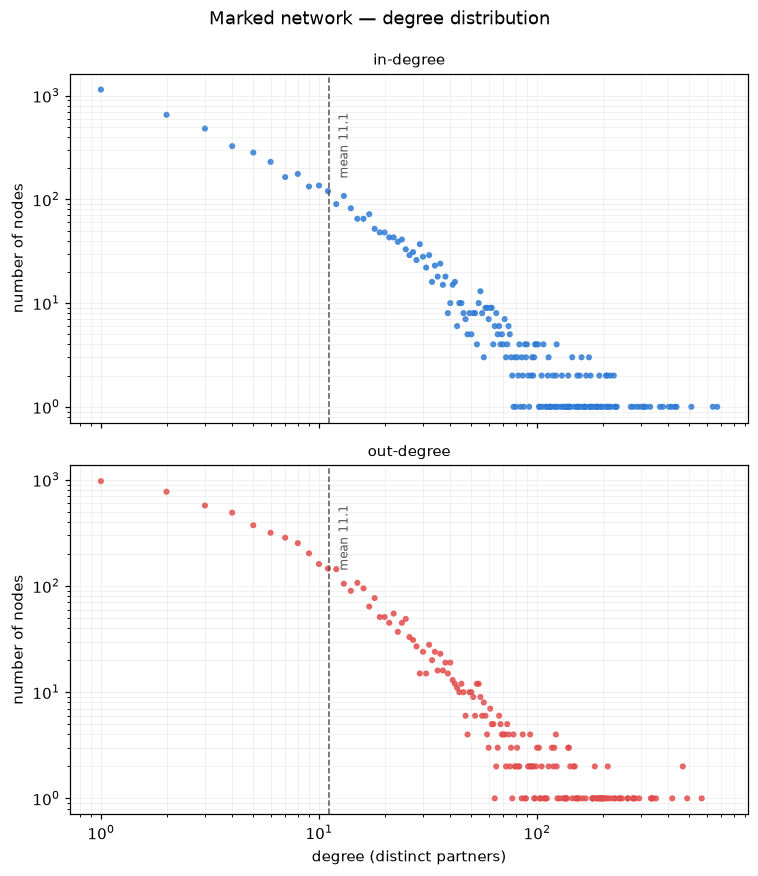

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
for ax, dv, title, colour in (
        (axes[0], ind,  'in-degree',  '#2a78d6'),
        (axes[1], outd, 'out-degree', '#e34948')):
    vals, counts = np.unique(dv[dv > 0], return_counts=True)
    ax.scatter(vals, counts, s=16, color=colour, edgecolors='none', alpha=0.85)
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_ylabel('number of nodes')
    ax.set_title(title, fontsize=10)
    ax.grid(True, which='both', alpha=0.2, linewidth=0.5)
    ax.axvline(dv.mean(), ls='--', color='#555', lw=1)
    ax.text(dv.mean() * 1.1, counts.max() * 0.6, f'mean {dv.mean():.1f}',
            fontsize=8, color='#555', rotation=90, va='top')
axes[1].set_xlabel('degree (distinct partners)')
plt.suptitle('Marked network — degree distribution', y=0.99, fontsize=12)
plt.tight_layout()
plt.show()


### In-degree vs out-degree — are the aggregators the origins?

Backs *"the correlation between the two measures is quite small with Spearman ρ = 0.19 and
Pearson's r = 0.127"* and the top-100 / top-20 overlap counts (4 and 1). Near-zero would mean
the two hub populations are essentially disjoint — being forwarded-*from* a lot tells you
little about how much a channel forwards, and vice versa.

In [5]:
def _rank(a):
    r = np.empty(len(a)); r[np.argsort(a)] = np.arange(len(a)); return r

spearman = np.corrcoef(_rank(ind), _rank(outd))[0, 1]
pearson  = np.corrcoef(ind, outd)[0, 1]
print(f'in-degree vs out-degree correlation (giant WCC, n = {G.vcount():,}):')
print(f'  Spearman rho = {spearman:.3f}   (rank correlation)')
print(f'  Pearson  r   = {pearson:.3f}   (linear correlation)')

print('\noverlap of the two hub populations:')
for k in (20, 50, 100):
    ti = set(np.argsort(ind)[::-1][:k].tolist()); to = set(np.argsort(outd)[::-1][:k].tolist())
    both = sorted(np.array(G.vs['name'])[list(ti & to)].tolist())
    print(f'  top-{k} in-hubs ∩ top-{k} out-hubs: {len(ti & to)}/{k}'
          + (f'  -> {both}' if both else ''))


in-degree vs out-degree correlation (giant WCC, n = 7,229):
  Spearman rho = 0.190   (rank correlation)
  Pearson  r   = 0.127   (linear correlation)

overlap of the two hub populations:
  top-20 in-hubs ∩ top-20 out-hubs: 1/20  -> ['solovievlive']
  top-50 in-hubs ∩ top-50 out-hubs: 1/50  -> ['solovievlive']
  top-100 in-hubs ∩ top-100 out-hubs: 4/100  -> ['boris_rozhin', 'krai_rodnoy', 'regnum_na', 'solovievlive']


### Top-20 hubs by degree — named

The elite aggregators (top in-degree) and origins (top out-degree), each annotated with its
rank in the *other* direction and whether it is a channel or a group. The names behind the
chapter's *"@tass_agency, @boris_rozhin or @medvedev_telegram"* and the single overlap,
@solovievlive.

In [6]:
_names = np.array(G.vs['name'])
_type = np.array([type_of.get(h, 'unknown') for h in _names])
_coreset = set(core.vs['name'])
_in_rank  = {i: r + 1 for r, i in enumerate(np.argsort(ind)[::-1])}
_out_rank = {i: r + 1 for r, i in enumerate(np.argsort(outd)[::-1])}

def _cross(order, k=20):
    return pd.DataFrame([{
        'handle': _names[i],
        'in-degree': int(ind[i]),
        'out-degree': int(outd[i]),
        'in-degree rank': _in_rank[i],
        'out-degree rank': _out_rank[i],
        'channel or group': _type[i],
        'language': lang.get(_names[i], 'unknown'),
        'subscribers': (f'{int(subs[_names[i]]):,}' if pd.notna(subs.get(_names[i], np.nan)) else '—'),
        'median views': (f'{int(med_views[_names[i]]):,}' if pd.notna(med_views.get(_names[i], np.nan)) else '—'),
        'SCC position': ('SCC core' if _names[i] in _coreset else
                         {'source': 'pure source', 'spreader': 'pure spreader', 'dual': 'pass-through'}[cls[i]]),
    } for i in order[:k]]).set_index('handle')

print('Top 20 by in-degree (aggregators — forward from N distinct sources):')
display(_cross(np.argsort(ind)[::-1]))
print('Top 20 by out-degree (origins — forwarded by N distinct channels):')
display(_cross(np.argsort(outd)[::-1]))


Top 20 by in-degree (aggregators — forward from N distinct sources):


,in-degree,out-degree,in-degree rank,out-degree rank,channel or group,language,subscribers,median views,SCC position
handle,,,,,,,,,
karga4,670,53,1,253,channel,ru,"22,578","1,115",SCC core
glavmedia,640,79,2,131,channel,ru,"67,013","5,188",SCC core
allratings,510,1,3,5851,channel,ru,796,86,SCC core
kb_announcments,436,33,4,506,channel,ru,"44,153","9,485",SCC core
karaulny,429,7,5,2495,channel,ru,"120,145","16,221",SCC core
nvreport,414,9,6,2104,channel,ru,"1,263",131,SCC core
kostisovesti,402,3,7,4238,channel,ru,182,8,SCC core
vesti_bule,378,1,8,6190,channel,ru,176,8,SCC core
kochka_lv,366,11,9,1775,channel,ru,"2,804",72,SCC core


Top 20 by out-degree (origins — forwarded by N distinct channels):


,in-degree,out-degree,in-degree rank,out-degree rank,channel or group,language,subscribers,median views,SCC position
handle,,,,,,,,,
bbbreaking,0,569,5801,1,channel,ru,"1,970,081","523,473",pure source
dimsmirnov175,8,488,2015,2,channel,ru,"324,592","111,481",SCC core
boris_rozhin,142,466,72,3,channel,ru,"746,799","362,946",SCC core
readovkanews,1,466,4323,4,channel,ru,"2,013,395","681,248",SCC core
tass_agency,0,417,7131,5,channel,ru,"566,079","46,928",pure source
solovievlive,276,351,16,6,channel,ru,"1,103,837","301,172",SCC core
mod_russia,2,340,3983,7,channel,ru,"592,928","123,865",SCC core
medvedev_telegram,0,335,6260,8,channel,ru,"1,730,126","2,244,164",pure source
sashakots,55,333,306,9,channel,ru,"478,191","276,922",SCC core


## §3.1.1 · Directionality of the information flows and channel roles

Where the forward edges run, by the role class of their endpoints. Pure sources can only be an
origin (no in-edges), pure spreaders only a target (no out-edges), so just four edge types are
possible. Splits reciprocity between the whole network and the dual-role middle — the only
nodes that *can* reciprocate. Backs the one-way-street reading and the 68.8 / 15.5 / 12.4 /
3.3% edge mix.

In [7]:
from collections import Counter
m_e = G.ecount()
pc = Counter((cls[e.source], cls[e.target]) for e in G.es)
role_edges = pd.DataFrame(
    [{'from': a, 'to': b, 'edges': c, 'share of edges': f'{c / m_e:.1%}'}
     for (a, b), c in sorted(pc.items(), key=lambda kv: -kv[1])]
).set_index(['from', 'to'])
display(role_edges)
print(f'reciprocity — whole network: {G.reciprocity():.1%}   |   '
      f'dual middle only (SCC core): {core.reciprocity():.1%}')


,,edges,share of edges
from,to,,
dual,dual,55405,68.8%
source,dual,12495,15.5%
dual,spreader,10000,12.4%
source,spreader,2676,3.3%


reciprocity — whole network: 11.7%   |   dual middle only (SCC core): 18.9%


### Are the roles genuine, or a crawl artifact?

The role split could reflect a node's position in the BFS crawl rather than its behaviour. Two
checks: (1) role share by crawl **depth** — an artifact would pile a role at one depth;
(2) **outside-forwarding** — do the pure sources forward from `id:NNN` origins *beyond* the
depth-2 cutoff as much as everyone else? If they were sources only by the cutoff, they should.
This is what licenses the chapter's split verdict: the pure-source role survives, the pure-
spreader role does not.

In [8]:
from collections import Counter as _Counter

_names = np.array(G.vs['name'])
_depth = np.array([depth_of.get(h, -1) for h in _names])
_rows = []
for d in (0, 1, 2):
    sel = _depth == d; c = _Counter(cls[sel]); nd = int(sel.sum())
    _rows.append({'depth': d, 'n': nd, 'source': f'{c["source"] / nd:.1%}',
                  'dual': f'{c["dual"] / nd:.1%}', 'spreader': f'{c["spreader"] / nd:.1%}'})
print('role share by crawl depth:')
display(pd.DataFrame(_rows).set_index('depth'))

# outside-forwarding: forwards from id:NNN origins beyond the depth-2 cutoff?
_outside = _Counter()
for r in csv.DictReader(open(DATA / 'edges_forward.csv')):
    if r['origin'].startswith('id:') and r['origin'] != r['target']:
        _outside[r['target']] += 1
_has = np.array([_outside.get(h, 0) > 0 for h in _names])
_src = cls == 'source'
print(f'forwards from outside the dataset (beyond the cutoff):')
print(f'  pure sources : {_has[_src].mean():.1%}')
print(f'  non-source   : {_has[~_src].mean():.1%}')
print('\n-> source pole flat across depth (23.2% / 24.8%) and rarely forwards from outside'
      ' -> genuine.\n   spreader share triples (4.6% -> 15.0%) with depth -> partly a depth-2 crawl artifact.')


role share by crawl depth:


,n,source,dual,spreader
depth,,,,
0,41,48.8%,51.2%,0.0%
1,1004,23.2%,72.2%,4.6%
2,6183,24.8%,60.2%,15.0%


forwards from outside the dataset (beyond the cutoff):
  pure sources : 21.4%
  non-source   : 76.9%

-> source pole flat across depth (23.2% / 24.8%) and rarely forwards from outside -> genuine.
   spreader share triples (4.6% -> 15.0%) with depth -> partly a depth-2 crawl artifact.


### Figure 2 · Audience by role — the downhill flow

*Thesis Figure 2.*

Median views per post (broadcast channels only) as an audience proxy. If content flows
source → dual → spreader, audience should fall along the way. Pairwise Mann–Whitney tests with
Holm correction, as reported in the chapter's footnote.

*Box = interquartile range, whiskers = 10th–90th percentile, outliers hidden; y-axis log-scaled.*

,n,median views,p25,p75
role,,,,
source,1655,4251,1434,15191
dual,4454,2427,716,8604
spreader,866,581,188,1853


Mann-Whitney U (two-sided), raw and Holm-corrected p-values:
    source vs dual     p = 1.29e-31   p(Holm) = 1.29e-31
    source vs spreader p = 1.07e-139   p(Holm) = 3.22e-139
      dual vs spreader p = 1.02e-94   p(Holm) = 2.04e-94

top-20 out-degree (origins)     median views: 328,044
top-20 in-degree  (aggregators) median views: 108


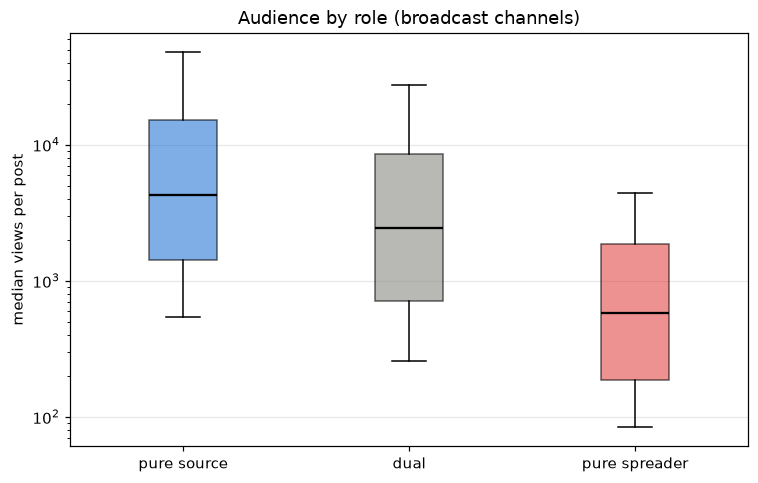

In [9]:
from scipy.stats import mannwhitneyu
from itertools import combinations

_mv = np.array([med_views.get(h, np.nan) for h in _names])
_typ = np.array([type_of.get(h, '?') for h in _names])
_ok = ~np.isnan(_mv) & (_mv > 0) & (_typ == 'channel')       # views = broadcast feature
_groups = {c: _mv[_ok & (cls == c)] for c in ('source', 'dual', 'spreader')}

display(pd.DataFrame([{'role': c, 'n': len(s), 'median views': int(np.median(s)),
                       'p25': int(np.percentile(s, 25)), 'p75': int(np.percentile(s, 75))}
                      for c, s in _groups.items()]).set_index('role'))

# pairwise Mann-Whitney U, Holm-corrected across the three comparisons (the figure
# reported in the chapter's footnote): sort p ascending, multiply by (m - rank), enforce
# monotonicity.
_pairs = list(combinations(('source', 'dual', 'spreader'), 2))
_raw_p = {(a, b): mannwhitneyu(_groups[a], _groups[b]).pvalue for a, b in _pairs}
_order = sorted(_raw_p, key=_raw_p.get)
_holm, _running = {}, 0.0
for _rank, _k in enumerate(_order):
    _running = max(_running, min(1.0, _raw_p[_k] * (len(_order) - _rank)))
    _holm[_k] = _running

print('Mann-Whitney U (two-sided), raw and Holm-corrected p-values:')
for a, b in _pairs:
    print(f'  {a:>8} vs {b:<8} p = {_raw_p[(a, b)]:.2e}   p(Holm) = {_holm[(a, b)]:.2e}')

_ti = np.argsort(ind)[::-1][:20]; _to = np.argsort(outd)[::-1][:20]
print(f'\ntop-20 out-degree (origins)     median views: {np.nanmedian(_mv[_to]):,.0f}')
print(f'top-20 in-degree  (aggregators) median views: {np.nanmedian(_mv[_ti]):,.0f}')

fig, ax = plt.subplots(figsize=(7, 4.5))
bp = ax.boxplot([_groups[c] for c in ('source', 'dual', 'spreader')], whis=(10, 90),
                showfliers=False, patch_artist=True, medianprops=dict(color='black', lw=1.5))
for patch, col in zip(bp['boxes'], ['#2a78d6', '#8a8a85', '#e34948']):
    patch.set_facecolor(col); patch.set_alpha(0.6)
ax.set_yscale('log'); ax.set_ylabel('median views per post')
ax.set_xticks([1, 2, 3]); ax.set_xticklabels(['pure source', 'dual', 'pure spreader'])
ax.set_title('Audience by role (broadcast channels)', fontsize=12)
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## §3.1.2 · Circulation and the strongly connected core

Refines the one-way-street reading: must a walk always move forward, or do some circulate?
Pure sources and pure spreaders (38.2%) can't sit on a returning loop by definition. Of the
dual-role middle, some are pass-throughs (never on a loop) and the rest form the **largest
strongly connected component** — a mutually-reachable core where every node reaches every
other. Then: where do the top-20 degree hubs sit relative to that core?

In [10]:
from collections import Counter as _Ctr
_names = np.array(G.vs['name'])
_coreset = set(core.vs['name'])
n = G.vcount()
n_src = int((cls == 'source').sum()); n_spr = int((cls == 'spreader').sum()); n_dual = int((cls == 'dual').sum())
n_core = len(_coreset); passt = n_dual - n_core

print('circulation decomposition of the giant WCC:')
print(f'  cannot loop (pure source + pure spreader) : {n_src + n_spr:,} ({(n_src + n_spr) / n:.1%})')
print(f'  dual pass-through (never on a loop)        : {passt:,} ({passt / n:.1%})')
print(f'  SCC core (mutually reachable, circulating) : {n_core:,} ({n_core / n:.1%})')

def _pos(i):
    return ('SCC core' if _names[i] in _coreset
            else {'source': 'pure source', 'spreader': 'pure spreader', 'dual': 'pass-through'}[cls[i]])

ti = np.argsort(ind)[::-1][:20]; to = np.argsort(outd)[::-1][:20]
print('\nposition of the degree hubs relative to the SCC core:')
print('  top-20 in-degree (aggregators):', dict(_Ctr(_pos(i) for i in ti)))
print('  top-20 out-degree (origins)   :', dict(_Ctr(_pos(i) for i in to)))
print('  biggest pure-source origins feeding INTO the core (outside it):',
      [str(_names[i]) for i in to if cls[i] == 'source'])


circulation decomposition of the giant WCC:
  cannot loop (pure source + pure spreader) : 2,760 (38.2%)
  dual pass-through (never on a loop)        : 713 (9.9%)
  SCC core (mutually reachable, circulating) : 3,756 (52.0%)

position of the degree hubs relative to the SCC core:
  top-20 in-degree (aggregators): {'SCC core': 15, 'pure spreader': 4, 'pass-through': 1}
  top-20 out-degree (origins)   : {'pure source': 5, 'SCC core': 13, 'pass-through': 2}
  biggest pure-source origins feeding INTO the core (outside it): ['bbbreaking', 'tass_agency', 'medvedev_telegram', 'neoficialniybezsonov', 'government_rus']


### Circulation vs flow-through — edge decomposition by core membership

How much forwarding *circulates inside* the SCC core versus *flows through* it? Partition all
directed edges into four mutually exclusive buckets by the core membership of their endpoints:
**internal** (both in core), **inflow** (outside → core), **outflow** (core → outside),
**bypass** (both outside). The four sum to every edge; the internal share is the chapter's
60.4%.

In [11]:
_coreset = set(core.vs['name'])
_in_core = np.array([h in _coreset for h in G.vs['name']])
_el = np.array(G.get_edgelist())
_s, _t = _in_core[_el[:, 0]], _in_core[_el[:, 1]]
m_e = G.ecount()
_buckets = [
    ('internal — both in SCC (circulating)',   int(( _s &  _t).sum())),
    ('inflow — tail outside, head inside',     int((~_s &  _t).sum())),
    ('outflow — tail inside, head outside',    int(( _s & ~_t).sum())),
    ('bypass — both outside the SCC',          int((~_s & ~_t).sum())),
]
edge_flow = pd.DataFrame([{'bucket': b, 'edges': c, 'share of edges': f'{c / m_e:.1%}'}
                          for b, c in _buckets]).set_index('bucket')
display(edge_flow)
print(f'sum check: {sum(c for _, c in _buckets):,} = {m_e:,} edges')


,edges,share of edges
bucket,,
internal — both in SCC (circulating),48675,60.4%
"inflow — tail outside, head inside",15172,18.8%
"outflow — tail inside, head outside",10790,13.4%
bypass — both outside the SCC,5939,7.4%


sum check: 80,576 = 80,576 edges


## §3.2 · The intersection of the Czecho-Slovak and Russian space

The chapter's main focus. The national spaces are not read off the language labels directly —
they are read off the **topology**, by running community detection and then asking which
communities coincide with a language.

### Table 2 · Community structure (Leiden)

*Thesis Table 2: communities — size, conductance, language composition.*

Leiden community detection (modularity objective) on the undirected projection of the giant
WCC. Per community: size, internal vs boundary edges, conductance (boundary ÷ min-volume;
lower = better-separated), and its language composition — the two most common languages with
their shares, and the Shannon entropy (bits) of the language mix (0 = monolingual).

In [12]:
import math, leidenalg
from collections import Counter

Gu = G.as_undirected(mode='collapse')
_part = leidenalg.find_partition(Gu, leidenalg.ModularityVertexPartition, seed=SEED, n_iterations=10)
_memb = np.array(_part.membership)
_ncomm = int(_memb.max() + 1)

# edge decomposition per community, on the directed network
_internal = np.zeros(_ncomm, dtype=np.int64)
_boundary = np.zeros(_ncomm, dtype=np.int64)
for e in G.es:
    a, b = _memb[e.source], _memb[e.target]
    if a == b:
        _internal[a] += 1
    else:
        _boundary[a] += 1; _boundary[b] += 1
_2m = 2 * G.ecount()
_vol = 2 * _internal + _boundary
_cond = _boundary / np.minimum(_vol, _2m - _vol)

# language composition per community
_lbn = np.array([lang.get(h, 'unknown') for h in G.vs['name']])
_rows = []
for c in range(_ncomm):
    _ix = np.where(_memb == c)[0]; _tot = len(_ix)
    _lc = Counter(_lbn[_ix]); _top = _lc.most_common(2)
    _d1, _n1 = _top[0]
    _d2, _n2 = _top[1] if len(_top) > 1 else ('—', 0)
    _ent = abs(-sum((k / _tot) * math.log2(k / _tot) for k in _lc.values()))   # bits; abs -> no -0.0
    _rows.append({'size': _tot, 'internal_edges': int(_internal[c]), 'boundary_edges': int(_boundary[c]),
                  'conductance': round(float(_cond[c]), 3),
                  'dominant_lang': _d1, 'share_lang': round(_n1 / _tot, 3),
                  'dominant_lang_2': _d2, 'share_lang_2': round(_n2 / _tot, 3),
                  'lang_entropy': round(_ent, 3)})
communities = (pd.DataFrame(_rows).sort_values('size', ascending=False)
               .reset_index(drop=True).rename_axis('community'))
display(communities)
print(f'{_ncomm} communities | modularity = {Gu.modularity(_memb):.3f} | seed = {SEED} (reproducible)')


,size,internal_edges,boundary_edges,conductance,dominant_lang,share_lang,dominant_lang_2,share_lang_2,lang_entropy
community,,,,,,,,,
0,1479,9945,13255,0.400,ru,0.973,unknown,0.024,0.197
1,1264,18285,17317,0.321,ru,0.955,unknown,0.030,0.342
2,1212,6392,5520,0.302,ru,0.976,unknown,0.022,0.172
3,833,5178,8243,0.443,ru,0.945,unknown,0.041,0.389
4,780,3086,4593,0.427,ru,0.981,unknown,0.018,0.144
5,431,2701,3902,0.419,ru,0.935,unknown,0.021,0.516
6,377,1706,2917,0.461,ru,0.968,unknown,0.029,0.217
7,325,1862,421,0.102,en,0.606,de,0.089,2.245
8,187,505,209,0.171,ru,0.604,uk,0.358,1.199


16 communities | modularity = 0.437 | seed = 42 (reproducible)


### Table 3 · Language assortativity and its per-language decomposition

*Thesis Table 3: per-language decomposition of the language assortativity coefficient.*

Newman's nominal assortativity of the language label, computed on the undirected projection.
**Czech and Slovak are treated as a single group `cssk`** (mutually intelligible, one national
space for this thesis), so the groups are ru / cssk / uk / en / other (`unknown`→`other`).

Then its **additive per-language decomposition** via the mixing matrix **e**: contribution of
group *i* to r = `(e_ii − a_i·b_i)/(1 − Σ a_j·b_j)` (these sum to r), the **observed** and
**expected in-language edge** counts (`e_ii` and `a_i·b_i` × total edges), their ratio and the
additive excess. A large obs/exp for a *small* group means genuine homophily, not Russian
dominance — the chapter's central move in reading this table.

In [13]:
# ---- groups: cs & sk merged into a single 'cssk' category ----
def _buck(l):
    if l in ('cs', 'sk'): return 'cssk'
    if l in ('ru', 'uk', 'en'): return l
    return 'other'                                       # everything else (incl. unknown)
_bl = [_buck(lang.get(h, 'unknown')) for h in G.vs['name']]
_bu = sorted(set(_bl)); _bi = {x: i for i, x in enumerate(_bu)}; _bc = [_bi[x] for x in _bl]
gu_lang = G.as_undirected(mode='collapse')
r_lang = gu_lang.assortativity_nominal(_bc, directed=False)
print(f'language assortativity (Newman nominal, undirected, cs+sk merged, {len(_bu)} groups): {r_lang:.4f}')
print(f'  directed variant (for reference): {G.assortativity_nominal(_bc, directed=True):.4f}')

# ---- per-language decomposition of r via the mixing matrix e ----
K = len(_bu)
e = np.zeros((K, K))
for ed in gu_lang.es:                       # symmetric mixing matrix on the undirected projection
    i, j = _bc[ed.source], _bc[ed.target]
    e[i, j] += 1; e[j, i] += 1
e /= e.sum()
a = e.sum(axis=1); b = e.sum(axis=0)        # row / column sums (symmetric -> a == b)
sab = float((a * b).sum())
M_und = gu_lang.ecount()                     # undirected edge total (for edge counts)
r_from_e = (np.trace(e) - sab) / (1 - sab)
print(f'\n[1] global r from e: {r_from_e:.4f}   (igraph assortativity: {r_lang:.4f})   '
      f'[undirected edges: {M_und:,}]')

N = G.vcount()
rows = []
for name in ['ru', 'cssk', 'uk', 'en', 'other']:
    if name not in _bi:
        continue
    i = _bi[name]; eii = e[i, i]; exp = a[i] * b[i]
    contrib = (eii - exp) / (1 - sab)
    nn = sum(1 for x in _bl if x == name)
    rows.append({'language': name, 'node_share': round(nn / N, 3),
                 'observed_in_edges': int(round(eii * M_und)),
                 'expected_in_edges': round(exp * M_und, 1),
                 'obs_in_frac': round(eii, 4), 'exp_in_frac': round(exp, 4),
                 'obs_over_exp': round(eii / exp, 2),
                 'additive_excess': round(eii - exp, 4),
                 'contribution_to_r': round(contrib, 4)})
lang_assort = pd.DataFrame(rows).set_index('language')
display(lang_assort)
print(f'[2] sum of contributions: {lang_assort["contribution_to_r"].sum():.4f}  ==  global r {r_from_e:.4f}')


language assortativity (Newman nominal, undirected, cs+sk merged, 5 groups): 0.5189
  directed variant (for reference): 0.5467

[1] global r from e: 0.5189   (igraph assortativity: 0.5189)   [undirected edges: 75,849]


,node_share,observed_in_edges,expected_in_edges,obs_in_frac,exp_in_frac,obs_over_exp,additive_excess,contribution_to_r
language,,,,,,,,
ru,0.895,69388,67032.3,0.9148,0.8838,1.04,0.0311,0.2702
cssk,0.015,650,7.2,0.0086,0.0001,90.28,0.0085,0.0737
uk,0.011,131,0.6,0.0017,0.0000,210.04,0.0017,0.0150
en,0.029,1067,24.3,0.0141,0.0003,43.85,0.0137,0.1196
other,0.050,418,65.5,0.0055,0.0009,6.38,0.0046,0.0404


[2] sum of contributions: 0.5189  ==  global r 0.5189


### Figure 3 · The Marked Network coloured by channel language

*Thesis Figure 3.*

Full forward giant WCC in a **DRL layout**, radially **compressed** (long distances shortened,
short ones kept), with **global degree-weighted repulsion** so hubs spread apart. Nodes are
true data-unit circles; **size** ∝ degree, **colour** = channel language (ru blue, cs red,
sk orange, uk yellow, en green, …). Edit the switches at the top of the code cell and re-run
it to tweak the figure.

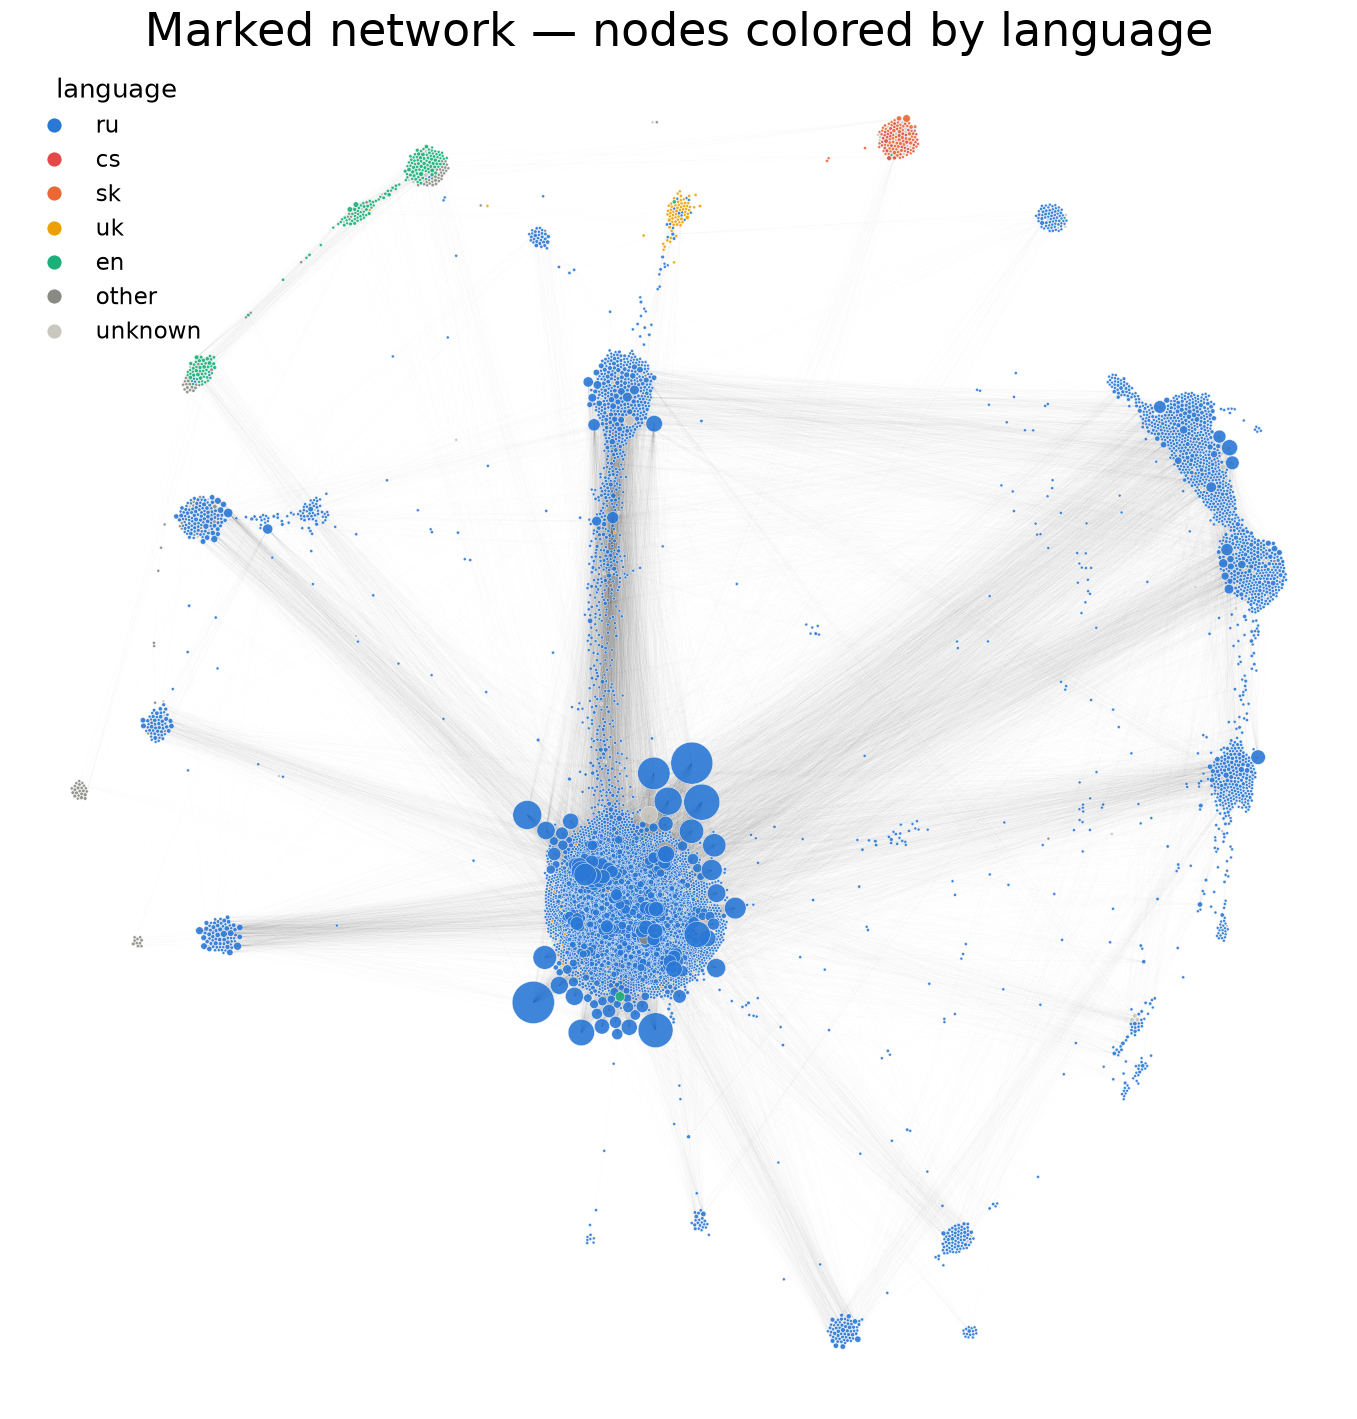

In [14]:
from matplotlib.collections import LineCollection, EllipseCollection
from matplotlib.colors import to_rgb, LinearSegmentedColormap
from matplotlib.cm import ScalarMappable
from scipy.spatial import cKDTree

# ============ TWEAK THESE, then re-run the cell (Shift+Enter) ============
SIZE_POWER          = 1.2     # node size vs degree (higher = hubs balloon more)
HUB_SIZE            = 0.016   # biggest-hub radius as a fraction of the frame
COMPRESS_PCT        = 10      # radial compression: lower = tighter/smaller graph (1..100)
LABELS              = 0      # how many top hubs to label
EDGE_ALPHA          = 0.05    # edge opacity
REPEL               = True    # spread nodes apart, degree-weighted (~10s)
REPEL_STRENGTH      = 1.05    # how hard they push apart (1.0..1.6)
PREVENT_ALL_OVERLAP = True   # strict zero-overlap packing; graph grows to fit (~13s)
LAYOUT_SEED         = 0       # change this number to reshuffle the DRL layout
# ========================================================================

_indf, _outdf = ind.astype(float), outd.astype(float)
htot = _indf + _outdf
# colour = channel language (palette + buckets defined in the construction cell)
hrgb = np.array([to_rgb(LANG_COLORS.get(l, LANG_COLORS['unknown'])) for l in G.vs['lang']])
hnames = np.array(G.vs['name'])
_rng = np.random.default_rng(42)

def hub_compress(coords, pct):
    if pct >= 100:
        return coords
    ctr = np.average(coords, axis=0, weights=htot); d = coords - ctr
    r = np.hypot(d[:, 0], d[:, 1]); r = np.where(r == 0, 1e-9, r); a = np.percentile(r, pct)
    return ctr + d * (a * np.arcsinh(r / a) / r)[:, None]

def hub_radii(coords, power, hub_frac):
    ext = max(np.ptp(coords[:, 0]), np.ptp(coords[:, 1]))
    return 0.0012 * ext + hub_frac * ext * (htot / htot.max()) ** power

def hub_repel(coords, radii, strength=1.05, full=False):
    # GLOBAL degree-weighted overlap repulsion: every node participates, higher-degree nodes
    # pushed more (weight ~ sqrt degree), movement-capped so nothing flings.
    # full=False -> clamp to original bbox (no growth); full=True -> no clamp + more iters.
    coords = coords.copy()
    w = (htot / htot.max()) ** 0.5 + 0.15
    iters = 220 if full else 150; pad = strength
    lo0, hi0 = coords.min(0), coords.max(0); ctr0 = (lo0 + hi0) / 2; span0 = float((hi0 - lo0).max())
    for _ in range(iters):
        pairs = cKDTree(coords).query_pairs(r=2 * radii.max() * pad, output_type='ndarray')
        if len(pairs) == 0:
            break
        i, j = pairs[:, 0], pairs[:, 1]; delta = coords[i] - coords[j]; dist = np.hypot(delta[:, 0], delta[:, 1])
        ov = (radii[i] + radii[j]) * pad - dist; m = ov > 0
        if not m.any():
            break
        i, j, dst, d2, ovm = i[m], j[m], dist[m], delta[m], ov[m]; z = dst < 1e-9
        dirv = np.where(z[:, None], _rng.standard_normal((len(i), 2)),
                        d2 / np.where(dst[:, None] < 1e-9, 1, dst[:, None]))
        dirv /= np.hypot(dirv[:, 0], dirv[:, 1])[:, None]
        wi, wj = w[i], w[j]; sN = wi + wj
        shift = np.zeros_like(coords)
        np.add.at(shift, i,  dirv * (wi / sN * ovm)[:, None])
        np.add.at(shift, j, -dirv * (wj / sN * ovm)[:, None])
        mag = np.hypot(shift[:, 0], shift[:, 1]); cap = radii * 0.6
        sc = np.where(mag > cap, cap / np.where(mag == 0, 1, mag), 1.0)
        coords = coords + shift * sc[:, None]
    if not full:
        lo, hi = coords.min(0), coords.max(0); span = float((hi - lo).max())
        if span > span0:
            ctr = (lo + hi) / 2; coords = ctr0 + (coords - ctr) * (span0 / span)
    return coords

def hub_layout(base_coords, power, hub_frac, compress_pct, repel, repel_strength, no_overlap):
    coords = hub_compress(base_coords, compress_pct)
    radii = hub_radii(coords, power, hub_frac)
    if no_overlap:
        coords = hub_repel(coords, radii, strength=repel_strength, full=True)
    elif repel:
        coords = hub_repel(coords, radii, strength=repel_strength, full=False)
    return coords

# base DRL layout, cached by LAYOUT_SEED (changing the seed reshuffles; other tweaks reuse it)
try:
    _LAYOUTS
except NameError:
    _LAYOUTS = {}
if LAYOUT_SEED not in _LAYOUTS:
    _LAYOUTS[LAYOUT_SEED] = np.array(G.layout_drl())
hub_base = _LAYOUTS[LAYOUT_SEED]

coords = hub_layout(hub_base, SIZE_POWER, HUB_SIZE, COMPRESS_PCT, REPEL, REPEL_STRENGTH, PREVENT_ALL_OVERLAP)
radii = hub_radii(coords, SIZE_POWER, HUB_SIZE)
FIG = 13                                # figure size (inches); all fonts scale with it
_fs = lambda frac: frac * FIG * 72      # points = fraction of the figure (dpi-independent)
fig, ax = plt.subplots(figsize=(FIG, FIG))
ax.add_collection(LineCollection([[coords[e.source], coords[e.target]] for e in G.es],
                                 colors='#000000', linewidths=0.06, alpha=EDGE_ALPHA, zorder=1))
o = np.argsort(htot)
ax.add_collection(EllipseCollection(2 * radii[o], 2 * radii[o], np.zeros(G.vcount()), units='xy',
    offsets=coords[o], transOffset=ax.transData, facecolors=hrgb[o],
    edgecolors='white', linewidths=0.3, alpha=0.9, zorder=2))
for i in np.argsort(htot)[::-1][:LABELS]:
    ax.text(coords[i, 0], coords[i, 1], hnames[i], fontsize=_fs(0.011), ha='center', va='center',
            zorder=3, bbox=dict(boxstyle='round,pad=0.15', fc='white', ec='none', alpha=0.7))
ax.set_aspect('equal'); ax.autoscale_view(); ax.set_axis_off()
ax.set_title('Marked network — nodes colored by language', fontsize=_fs(0.032))
_present = [l for l in ['ru', 'cs', 'sk', 'uk', 'en', 'other', 'unknown'] if l in set(G.vs['lang'])]
_handles = [plt.Line2D([0], [0], marker='o', ls='', mfc=LANG_COLORS[l], mec='white',
                       ms=_fs(0.011), label=l) for l in _present]
ax.legend(handles=_handles, title='language', loc='upper left', frameon=False,
          fontsize=_fs(0.016), title_fontsize=_fs(0.018))
plt.tight_layout(); plt.show()


### Table 4 · Community topics — c-TF-IDF over pooled messages

*Thesis Table 4: top-20 distinctive terms per community.*

What is each Leiden community *about*? Every community's member channels contribute their
message term-bag (`data_final/channel_terms.json` — top-120 letters-only tokens per channel,
rebuilt from the raw scraped messages by `scripts/build_terms_final.py`), pooled into one
document per community. We then strip **stopwords for every language present in the network** —
the union of [`stopwordsiso`](https://pypi.org/project/stopwordsiso/) lists, plus URL/junk
tokens, engagement boilerplate (subscribe / follow / share), channel-handle tokens and pure
numbers — and rank each community's vocabulary by **class-based TF-IDF** (community =
document): `tf` = the term's share of the community's tokens, `idf = log((1+N)/(1+df)) + 1`
over the *N* communities. High score = the vocabulary that most distinguishes a community from
the others. Communities with < 20 channels are omitted; community ids match Table 2.

In [15]:
import json, math, re
import leidenalg
import stopwordsiso as _sw

# ---- Leiden communities (self-contained; same partition + numbering as Table 2) ----
_Gu = G.as_undirected(mode='collapse')
_part = leidenalg.find_partition(_Gu, leidenalg.ModularityVertexPartition,
                                 seed=SEED, n_iterations=10)
_memb = np.array(_part.membership)
_ncomm = int(_memb.max() + 1)
_gv = np.array(G.vs['name'])
_sizes = Counter(_memb.tolist())

# ---- multilingual filter -----------------------------------------------------------
# authoritative stopwords for EVERY language present in the network (stopwordsiso covers
# 27/30 — mk/zh-cn/unknown have no list), + URL/boilerplate junk + engagement CTAs +
# channel-handle tokens (forwarded-in usernames) + pure numbers. The union is safe: the
# scripts barely overlap, so a stopword in one language rarely eats a content word in another.
_present = {lang.get(h, 'unknown') for h in _gv}
_langs_used = sorted(_present & set(_sw.langs()))
_STOP = set(_sw.stopwords(_langs_used))
_JUNK = {'https', 'http', 'www', 'com', 'org', 'html', 'php', 'amp', 'quot', 'nbsp'}
_CTA = {'подписаться', 'подпишись', 'подписывайтесь', 'подписка', 'подписки',
        'подпишитесь', 'подписчики', 'репост', 'канал', 'канала', 'телеграм',
        'sledujte', 'odber', 'odoberajte', 'zdielajte', 'zdieľajte', 'sdilejte',
        'subscribe', 'follow', 'channel', 'telegram', 'share', 'chat', 'dołącz'}
_STOP |= _JUNK | _CTA
_HANDLES = {h.lower() for h in _gv}                       # tokens that are node handles
_isnum = re.compile(r'^\d+$')
def _keep(tok):
    return (len(tok) >= 3 and tok not in _STOP and tok not in _HANDLES
            and not _isnum.match(tok))

# ---- pool member channels' term bags into one document per community ---------------
_terms = json.load(open(DATA / 'channel_terms.json'))     # frozen bundle, rebuilt by build_terms_final.py
_bag = [Counter() for _ in range(_ncomm)]
_tot = np.zeros(_ncomm)
for _i, _h in enumerate(_gv):
    _c = _memb[_i]; _tb = _terms.get(_h)
    if not _tb:
        continue
    for _w, _n in _tb['terms'].items():
        _wl = _w.lower()
        if _keep(_wl):
            _bag[_c][_wl] += _n
            _tot[_c] += _n

# ---- class-based TF-IDF (c-TF-IDF): community = document ---------------------------
# tf = term's share of the community's tokens; idf = log((1+N)/(1+df))+1 over the N
# communities. High score = vocabulary distinctive to this community vs. the others.
MIN_SIZE = 20                                             # skip tiny noise communities
_big = [c for c in range(_ncomm) if _sizes[c] >= MIN_SIZE]
_df = Counter()
for _c in _big:
    for _w in _bag[_c]:
        _df[_w] += 1
_Ndoc = len(_big)

def _top_terms(c, k=20):
    _den = _tot[c] or 1
    _sc = [(_w, (_n / _den) * (math.log((1 + _Ndoc) / (1 + _df[_w])) + 1))
           for _w, _n in _bag[c].items()]
    _sc.sort(key=lambda x: -x[1])
    return [w for w, _ in _sc[:k]]

print(f'stopwords: {len(_STOP):,} (stopwordsiso for {len(_langs_used)} present langs + junk/CTA) | '
      f'handle tokens dropped: {len(_HANDLES):,}')
print(f'communities with >= {MIN_SIZE} channels: {_Ndoc} of {_ncomm}\n')

_rows = []
for _c in sorted(_big, key=lambda c: -_sizes[c]):
    _ix = np.where(_memb == _c)[0]
    _lc = Counter(lang.get(_gv[i], 'unknown') for i in _ix).most_common(3)
    _rows.append({'community': _c, 'n': _sizes[_c],
                  'languages (top 3)': ', '.join(f'{l} {n}' for l, n in _lc),
                  'distinctive terms (c-TF-IDF)': ', '.join(_top_terms(_c))})
community_terms = pd.DataFrame(_rows).set_index('community')
pd.set_option('display.max_colwidth', None)
display(community_terms)


stopwords: 9,481 (stopwordsiso for 23 present langs + junk/CTA) | handle tokens dropped: 7,229
communities with >= 20 channels: 13 of 16



,n,languages (top 3),distinctive terms (c-TF-IDF)
community,,,
0,1479,"ru 1439, unknown 36, bg 1","россии, сша, января, украине, украины, области, страны, заявил, рублей, млн, млрд, власти, глава, войны, всу, президента, ранее, сво, компании, российских"
1,1264,"ru 1207, unknown 38, bg 7","всу, россии, украине, украины, сша, области, сво, украинских, новость, заявил, украина, января, чат, направлении, днр, предложить, видео, страны, нато, украинские"
2,1212,"ru 1183, unknown 27, bg 2","области, россии, января, рублей, aurora, региона, млн, глава, города, работы, губернатор, news, область, края, губернатора, районе, детей, тыс, млрд, власти"
3,833,"ru 787, unknown 34, bg 3","россии, украины, января, украине, сша, людей, войны, всу, русских, сво, поэтому, жизни, области, русские, страны, наших, русского, русской, церкви, нашей"
4,780,"ru 765, unknown 14, tr 1","россии, области, января, днр, лнр, республики, херсонской, работы, города, рублей, детей, всу, чат, новых, территории, народной, запорожской, новость, украины, российской"
5,431,"ru 403, unknown 9, uk 6","россии, января, украине, украины, сша, азербайджана, заявил, страны, беларуси, молдовы, президент, молдова, президента, области, министр, республики, санду, беларусь, глава, тенге"
6,377,"ru 365, unknown 11, ar 1","россии, января, рублей, области, сочи, дагестана, республики, рен, кубань, рбк, глава, осетии, города, украине, районе, подробнее, видео, дагестан, работы, района"
7,325,"en 197, de 29, es 24","ukraine, russian, ukrainian, forces, twitter, police, people, ucrania, afu, soledar, military, armed, bakhmut, community, kiev, strategy, expert, biden, slg, briefings"
8,187,"ru 113, uk 67, unknown 4","україни, україні, які, оборони, подскажите, израиле, області, вже, року, украина, щоб, зсу, окупантів, израиля, росії, січня, сьогодні, реальная, після, буде"


### Figure 4 · Community meta-graph

*Thesis Figure 4: Marked Network communities collapsed, showing language composition.*

The giant WCC contracted to one node per Leiden community. Node **area** is proportional to
community population, each node is a **pie of its language composition**, and edge width is
the number of cross-community forward relations (undirected, collapsed). Layout: weighted
Fruchterman–Reingold on the meta-graph, with a seeded random start so `LAYOUT_SEED` is a
reproducible reroll and an overlap-removal pass so nodes/labels stay legible.

layout seed = 473857   (copy this into LAYOUT_SEED to lock it in)


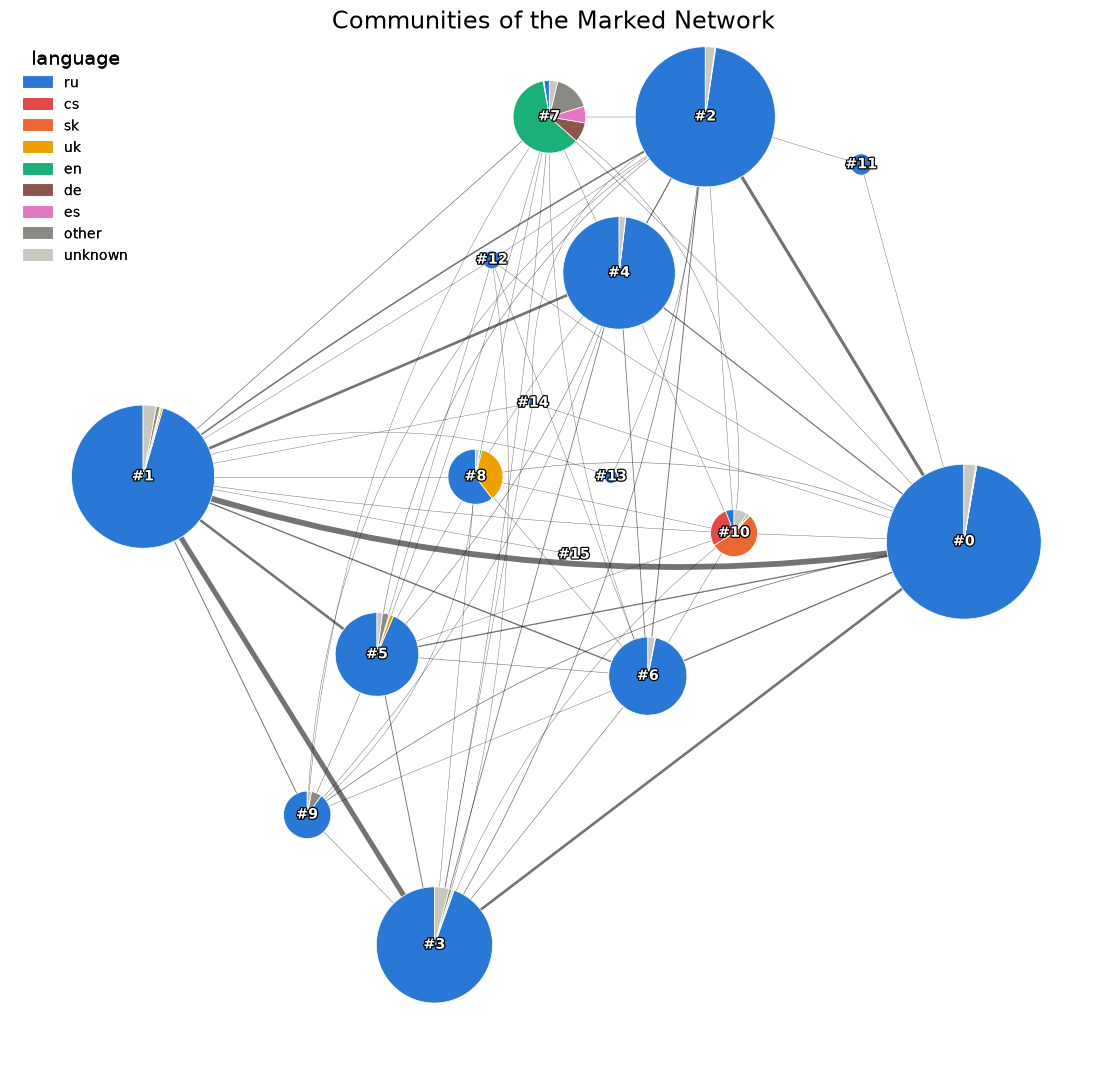

In [16]:
import random
import leidenalg
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# --- communities (same partition + numbering as Table 2) ---
memb = np.array(leidenalg.find_partition(G.as_undirected(mode='collapse'),
                leidenalg.ModularityVertexPartition, seed=SEED, n_iterations=10).membership)
# local palette adds German/Spanish so they get their own pie slices (elsewhere they fold into 'other')
_MC = dict(LANG_COLORS, de='#8c564b', es='#e377c2')      # brown = de, pink = es
def _mbucket(l): return l if l in _MC else ('unknown' if l == 'unknown' else 'other')
langs_arr = np.array([_mbucket(lang.get(h, 'unknown')) for h in G.vs['name']])

# --- contract the giant WCC into one meta-node per community (deterministic) ---
comm_ids   = sorted(set(memb.tolist()))
csize      = {c: int((memb == c).sum()) for c in comm_ids}
cid_to_idx = {c: i for i, c in enumerate(comm_ids)}
n_comm     = len(comm_ids)
sizes      = np.array([csize[c] for c in comm_ids], float)
lang_mix   = {c: Counter(langs_arr[memb == c].tolist()) for c in comm_ids}

src = memb[[e.source for e in G.es]]; dst = memb[[e.target for e in G.es]]
pair_w = Counter()
for a, b in zip(src.tolist(), dst.tolist()):
    if a != b:
        pair_w[tuple(sorted((a, b)))] += 1

cg = ig.Graph(directed=False); cg.add_vertices(n_comm)
cg.add_edges([(cid_to_idx[a], cid_to_idx[b]) for a, b in pair_w])
cg.es['weight'] = [pair_w[p] for p in pair_w]

# ── re-run this cell to try a new layout ──────────────────────────────────
LAYOUT_SEED = 473857    # int = reproducible; None = draw a fresh random seed (printed below)
LAYOUT_ALGO = 'fr'      # 'fr' | 'fr_noweight' | 'kk' | 'drl' | 'circle' | 'random'
LOG_SIZE    = False     # False = area ∝ population; True = logarithmic sizing (mellows the gap)
r_max       = 0.17      # radius of the largest community
SPREAD      = 2.5       # min gap between nodes = (r_i + r_j) * SPREAD; raise to space out
ROTATE      = 90        # rotate the whole graph by this many degrees (CCW)
EDGE_CLEAR  = 0.012     # gap kept between an edge and any node it is NOT incident to (0 = off)
PIN = {                 # hand-tuned template (from the intersection notebook); x/y in -1..+1
     0: (-0.57, -1.00),  1: (-0.42,  1.00),  2: ( 0.41, -0.37),  3: (-1.50,  0.29),
     4: ( 0.05, -0.16),  5: (-0.83,  0.43),  6: (-0.88, -0.23),  7: ( 0.41,  0.01),
     8: (-0.42,  0.19),  9: (-1.20,  0.60), 10: (-0.55, -0.44), 11: (0.3, -0.75),
    12: ( 0.08,  0.15), 13: (-0.42, -0.14), 14: (-0.25,  0.05), 15: (-0.60, -0.05),
    16: (-0.53,  0.07), 17: (-1.60, -0.12),
}
# ──────────────────────────────────────────────────────────────────────────

if LAYOUT_SEED is None:
    LAYOUT_SEED = int(np.random.default_rng().integers(0, 1_000_000))
print(f'layout seed = {LAYOUT_SEED}   (copy this into LAYOUT_SEED to lock it in)')

# seeded random start coords make LAYOUT_SEED actually bite (the weighted meta-graph is
# near-complete among the big communities, so FR alone converges to the same blob).
random.seed(LAYOUT_SEED); rng = np.random.default_rng(LAYOUT_SEED)
start = rng.uniform(-1, 1, (n_comm, 2)).tolist()
if LAYOUT_ALGO == 'fr':
    lay = cg.layout_fruchterman_reingold(weights='weight', seed=start)
elif LAYOUT_ALGO == 'fr_noweight':
    lay = cg.layout_fruchterman_reingold(seed=start)
elif LAYOUT_ALGO == 'kk':
    lay = cg.layout_kamada_kawai(seed=start)
elif LAYOUT_ALGO == 'drl':
    lay = cg.layout_drl(weights='weight')
elif LAYOUT_ALGO == 'circle':
    lay = cg.layout_circle()
elif LAYOUT_ALGO == 'random':
    lay = start
coords = np.array(lay if isinstance(lay, list) else lay.coords, float)
coords -= coords.mean(0); coords /= np.abs(coords).max() + 1e-9

metric = np.log10(sizes + 1) if LOG_SIZE else np.sqrt(sizes)
rad    = r_max * metric / metric.max()

# push overlapping circles apart so every node + label stays legible
for _ in range(600):
    moved = False
    for i in range(n_comm):
        for j in range(i + 1, n_comm):
            d = coords[j] - coords[i]; dist = float(np.hypot(*d)); min_d = (rad[i] + rad[j]) * SPREAD
            if dist < min_d:
                if dist < 1e-9:
                    d = np.array([1e-3 * (j - i + 1), 1e-3]); dist = float(np.hypot(*d))
                u = d / dist; shift = (min_d - dist) / 2
                coords[i] -= u * shift; coords[j] += u * shift; moved = True
    if not moved:
        break

if PIN:
    fx, fy = coords[:, 0].copy(), coords[:, 1].copy()
    cx0, cy0 = (fx.min() + fx.max()) / 2, (fy.min() + fy.max()) / 2
    hx, hy   = (fx.max() - fx.min()) / 2, (fy.max() - fy.min()) / 2
    for cid, (u, v) in PIN.items():
        if cid in cid_to_idx:                     # our partition has 16 communities (0-15)
            coords[cid_to_idx[cid]] = [cx0 + u * hx, cy0 + v * hy]

if ROTATE % 360:
    th = np.deg2rad(ROTATE); R = np.array([[np.cos(th), np.sin(th)], [-np.sin(th), np.cos(th)]])
    ctr = coords.mean(0); coords = (coords - ctr) @ R + ctr

pos  = {c: coords[cid_to_idx[c]] for c in comm_ids}
rmap = {c: rad[cid_to_idx[c]] for c in comm_ids}
xs, ys = coords[:, 0], coords[:, 1]
lang_order = ['ru', 'cs', 'sk', 'uk', 'en', 'de', 'es', 'other', 'unknown']
dominant   = lambda c: max(lang_mix[c].items(), key=lambda kv: kv[1])[0]

FIG = 13                                # figure width (inches); all fonts scale with it
_fs = lambda frac: frac * FIG * 72      # points = fraction of the figure (size-independent)
fig, ax = plt.subplots(figsize=(FIG, FIG * 10 / 13))

# edges — width ∝ cross-community relations; each edge bends clear of any node it is
# NOT incident to, so no community pie ever sits on top of an edge that isn't its own.
from matplotlib.path import Path as _MPath
from matplotlib.patches import PathPatch as _PathPatch
_obst = {c: (np.asarray(pos[c], float), rmap[c] + EDGE_CLEAR) for c in comm_ids}

def _route(a, b):
    """quadratic control point for edge a-b that clears every non-incident node
    (smallest bend that works); None if the straight segment is already clear."""
    p0, p1 = np.asarray(pos[a], float), np.asarray(pos[b], float)
    chord = p1 - p0; L = float(np.hypot(*chord))
    if L < 1e-9 or EDGE_CLEAR <= 0:
        return None
    nv = np.array([-chord[1], chord[0]]) / L
    obs = [(ctr, R) for c, (ctr, R) in _obst.items() if c not in (a, b)]
    if not obs:
        return None
    ts = np.linspace(0, 1, 48)[:, None]
    def worst_clear(k):
        ctrl = (p0 + p1) / 2 + k * nv
        B = (1 - ts) ** 2 * p0 + 2 * (1 - ts) * ts * ctrl + ts ** 2 * p1
        return min((np.hypot(*(B - ctr).T) - R).min() for ctr, R in obs)
    if worst_clear(0.0) >= 0:
        return None
    for mag in np.linspace(0.03, 0.75, 40):
        for k in (mag, -mag):
            if worst_clear(k) >= 0:
                return (p0 + p1) / 2 + k * nv
    return (p0 + p1) / 2 + max((0.75, -0.75), key=worst_clear) * nv   # least-bad fallback

max_w = max(pair_w.values())
for (a, b), w in pair_w.items():
    lw = 0.3 + 3.5 * (w / max_w)
    ctrl = _route(a, b)
    if ctrl is None:
        ax.plot([pos[a][0], pos[b][0]], [pos[a][1], pos[b][1]], color='black',
                lw=lw, alpha=0.55, zorder=1, solid_capstyle='round')
    else:
        ax.add_patch(_PathPatch(_MPath([pos[a], ctrl, pos[b]],
            [_MPath.MOVETO, _MPath.CURVE3, _MPath.CURVE3]),
            fill=False, edgecolor='black', lw=lw, alpha=0.55, zorder=1, capstyle='round'))

# nodes — each a pie of its language composition; community id centred
for c in comm_ids:
    cx, cy = pos[c]; r = rmap[c]; tot = sum(lang_mix[c].values()); theta = 90.0
    for lg in lang_order:
        nn = lang_mix[c].get(lg, 0)
        if not nn:
            continue
        ang = 360.0 * nn / tot
        ax.add_patch(mpatches.Wedge((cx, cy), r, theta, theta + ang,
                     facecolor=_MC[lg], edgecolor='white', lw=0.5, zorder=3))
        theta += ang
    ax.text(cx, cy, f'#{c}', ha='center', va='center', fontweight='bold', fontsize=_fs(0.010),
            color='white', zorder=4, path_effects=[pe.withStroke(linewidth=1.6, foreground='black')])

# legend 1 — language colours
present = [lg for lg in lang_order if any(lg in lang_mix[c] for c in comm_ids)]
leg1 = ax.legend(handles=[mpatches.Patch(color=_MC[lg], label=lg) for lg in present],
                 loc='upper left', frameon=False, fontsize=_fs(0.010), title='language',
                 title_fontsize=_fs(0.013))
ax.add_artist(leg1)

m = 0.12
ax.set_xlim(xs.min() - r_max - m, xs.max() + r_max + m)
RAISE = 0.20   # move the network up toward the title (trim top whitespace), data units
_top_floor = max(pos[c][1] + rmap[c] for c in comm_ids) + 0.02   # never clip the top node
ax.set_ylim(ys.min() - r_max - m, max(ys.max() + r_max + m - RAISE, _top_floor))
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Communities of the Marked Network', fontsize=_fs(0.017))
plt.tight_layout(); plt.show()


### Community 10 (Czech–Slovak) — its boundary with the rest of the network

The cs/sk community's interface on the **directed forward network**. **Import** = outside →
member (a community-10 member reposts *from* an outside channel); **export** = member →
outside. Backs *"105 edges running into the Czech-Slovak channel or group nodes and only 23
running from the community's nodes to the outside"* and the exporter list. Everything is
recomputed on the current canonical 16-community `leidenalg` partition — the same one behind
Table 2 — with no cached membership.

community 10: 136 members   (expected: 136)
  language mix: [('sk', 74), ('cs', 38), ('unknown', 13), ('ru', 8), ('sl', 1), ('pl', 1), ('en', 1)]


,count,share
measure,,
community members,136,
import edges (outside → C10),105,
export edges (C10 → outside),23,
members touching the outside,27,20%


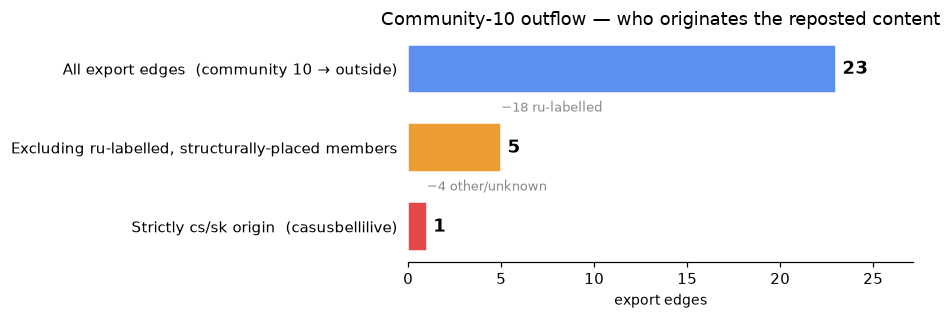

In [17]:
import leidenalg
import matplotlib.pyplot as plt

# canonical 16-community partition (identical to Table 2) — recomputed, no cached membership
c10_memb = np.array(leidenalg.find_partition(G.as_undirected(mode='collapse'),
                    leidenalg.ModularityVertexPartition, seed=SEED, n_iterations=10).membership)
c10_gv  = np.array(G.vs['name'])
C10 = 10
c10_set = set(np.where(c10_memb == C10)[0].tolist())
print(f'community {C10}: {len(c10_set)} members   (expected: 136)')
print('  language mix:', Counter(lang.get(c10_gv[i], "unknown") for i in c10_set).most_common())

# directed forward network — edge = origin -> forwarder (content flows source -> reposter):
#   import = outside -> member (member reposts from outside); export = member -> outside
c10_imp = [(e.source, e.target) for e in G.es if e.target in c10_set and e.source not in c10_set]
c10_exp = [(e.source, e.target) for e in G.es if e.source in c10_set and e.target not in c10_set]
_touch  = {t for _, t in c10_imp} | {s for s, _ in c10_exp}

# discount chain: total exports -> ru-labelled removed -> remainder -> strictly cs/sk (named)
_tot  = len(c10_exp)
_ru   = sum(1 for s, _ in c10_exp if lang.get(c10_gv[s]) == 'ru')
_rem  = _tot - _ru
_cssk = [(s, t) for s, t in c10_exp if lang.get(c10_gv[s]) in ('cs', 'sk')]
_cssk_handles = sorted({str(c10_gv[s]) for s, _ in _cssk})
_oth  = _rem - len(_cssk)

# --- boundary summary (compact table) ---
boundary_summary = pd.DataFrame(
    [('community members',            len(c10_set), ''),
     ('import edges (outside → C10)', len(c10_imp), ''),
     ('export edges (C10 → outside)', len(c10_exp), ''),
     ('members touching the outside', len(_touch),  f'{len(_touch) / len(c10_set):.0%}')],
    columns=['measure', 'count', 'share']).set_index('measure')
display(boundary_summary)

# --- discount-chain funnel (Figure): who originates the content the outside reposts ---
_stages = [('All export edges  (community 10 → outside)',            _tot,       '#5b8ff0'),
           ('Excluding ru-labelled, structurally-placed members',        _rem,       '#eb9d34'),
           (f'Strictly cs/sk origin  ({", ".join(_cssk_handles)})',      len(_cssk), '#e34948')]
_drops = [None, f'−{_ru} ru-labelled', f'−{_oth} other/unknown']
fig, ax = plt.subplots(figsize=(8.5, 3.0))
_y = np.arange(len(_stages))[::-1]
for (_lbl, _val, _col), _yy, _dr in zip(_stages, _y, _drops):
    ax.barh(_yy, _val, color=_col, edgecolor='white', height=0.62, zorder=2)
    ax.text(_val + _tot * 0.015, _yy, f'{_val}', va='center', ha='left', fontweight='bold', fontsize=12)
    if _dr:
        ax.annotate(_dr, xy=(_val, _yy + 0.42), fontsize=8.5, color='#888', ha='left', va='bottom')
ax.set_yticks(_y); ax.set_yticklabels([s[0] for s in _stages], fontsize=9.5)
ax.set_xlim(0, _tot * 1.18); ax.set_xlabel('export edges', fontsize=9)
ax.set_title('Community-10 outflow — who originates the reposted content', fontsize=11.5)
for _sp in ('top', 'right', 'left'):
    ax.spines[_sp].set_visible(False)
ax.tick_params(left=False)
plt.tight_layout(); plt.show()

In [18]:
# import-source table: import edges (outside -> community 10) by origin community + language
_rows = []
for _oc, _ct in Counter(c10_memb[s] for s, _ in c10_imp).most_common():
    _dl = Counter(lang.get(c10_gv[i], 'unknown')
                  for i in np.where(c10_memb == _oc)[0]).most_common(1)[0][0]
    _rows.append({'Origin community': int(_oc), 'Dominant language': _dl,
                  'Import edges': _ct, 'Share': f'{100 * _ct / len(c10_imp):.1f}%'})
import_sources = pd.DataFrame(_rows).set_index('Origin community')
print(f'Import sources — {len(c10_imp)} edges (outside → community 10), by origin community:')
display(import_sources)

Import sources — 105 edges (outside → community 10), by origin community:


,Dominant language,Import edges,Share
Origin community,,,
1,ru,33,31.4%
7,en,27,25.7%
6,ru,13,12.4%
5,ru,11,10.5%
0,ru,10,9.5%
4,ru,4,3.8%
2,ru,3,2.9%
3,ru,3,2.9%
8,ru,1,1.0%


In [19]:
# exporters table: community-10 members carrying the outflow (member -> outside)
_erows = [{'Handle': str(c10_gv[s]), 'Language': lang.get(c10_gv[s], 'unknown'),
           'Type': type_of.get(c10_gv[s], '?'), 'Export edges': _ct}
          for s, _ct in Counter(s for s, _ in c10_exp).most_common()]
exporters = pd.DataFrame(_erows).set_index('Handle')
print(f'Exporters — {exporters.shape[0]} community-10 members carry the {len(c10_exp)} export edges:')
display(exporters)

# --- quick lookup: where does the one genuine cs/sk exporter (casusbellilive) export to? ---
# target/community/group are reproducible from data_final; the exact post URL was resolved once
# from the raw scraped forward header (source_msg_id) — that message id is not in data_final.
_cbi = np.where(c10_gv == 'casusbellilive')[0]
for _s, _t in ([(s, t) for s, t in c10_exp if s == int(_cbi[0])] if len(_cbi) else []):
    _th = str(c10_gv[_t])
    print(f'casusbellilive exports -> {_th}  |  community {int(c10_memb[_t])}  |  '
          f'language group {lang.get(_th, "unknown")}  |  {type_of.get(_th, "?")}')
    # the two subscriber counts the chapter names for this one genuine cs/sk export
    print(f'  subscribers : casusbellilive {subs.get("casusbellilive", float("nan")):,.0f}'
          f'  ->  {_th} {subs.get(_th, float("nan")):,.0f}')
    if _th == 'bulgariaz':                       # bulgariaz msg 15940 <- casusbellilive msg 88310
        print(f'  reposted at : https://t.me/{_th}/15940')
        print(f'  original    : https://t.me/casusbellilive/88310   ("Miss Ukrajiny na Miss Univers 2023")')
    else:
        print(f'  (post URL was resolved for bulgariaz; target is now {_th} — re-resolve from raw data)')

Exporters — 10 community-10 members carry the 23 export edges:


,Language,Type,Export edges
Handle,,,
news_1tv,ru,channel,10
gtrktomsk,ru,channel,2
gtrk_nn,ru,channel,2
technikus_news,unknown,empty,2
priroda_animal,ru,channel,2
ruskistatek,pl,channel,1
vesti_don,ru,channel,1
vesti_zauralie,ru,channel,1
casusbellilive,sk,channel,1


casusbellilive exports -> bulgariaz  |  community 1  |  language group bg  |  channel
  subscribers : casusbellilive 40,463  ->  bulgariaz 4,517
  reposted at : https://t.me/bulgariaz/15940
  original    : https://t.me/casusbellilive/88310   ("Miss Ukrajiny na Miss Univers 2023")


### Community 10 — full membership

Every channel in the Czech–Slovak community, and separately the members **not** labelled
cs/sk — the structurally-placed foreign channels the chapter's footnote discusses (13
misplaced, of which 11 unknowns are in fact Czech or Slovak channels empty for the collection
window).

In [20]:
# all community-10 members
def _fmt_subs(h):
    v = subs.get(h, np.nan)
    return f'{int(v):,}' if pd.notna(v) else '—'
_rows = [{'Handle': str(c10_gv[i]), 'Language': lang.get(c10_gv[i], 'unknown'),
          'Type': type_of.get(c10_gv[i], '?'),
          'Subscribers': _fmt_subs(c10_gv[i]), 'Messages': vol.get(c10_gv[i], 0)}
         for i in sorted(c10_set)]
community10_channels = (pd.DataFrame(_rows)
                        .sort_values(['Language', 'Messages'], ascending=[True, False])
                        .reset_index(drop=True))
print(f'All {len(community10_channels)} community-10 members '
      f'({dict(Counter(community10_channels.Language))}):')
display(community10_channels)

All 136 community-10 members ({'cs': 38, 'en': 1, 'pl': 1, 'ru': 8, 'sk': 74, 'sl': 1, 'unknown': 13}):


,Handle,Language,Type,Subscribers,Messages
0,czkulovyblesk,cs,group,563,5063
1,bn4jeytq6rvkmtnk,cs,channel,"10,524",4188
2,selskyrozum,cs,channel,"12,443",3819
3,cz24news,cs,channel,"29,718",2914
4,conematevedet,cs,channel,"8,165",2435
...,...,...,...,...,...
131,marianduris,unknown,empty,"2,932",0
132,michalapetr,unknown,empty,"6,822",0
133,newsfrontsk,unknown,empty,"12,771",0
134,rozsirenevedomi,unknown,empty,"3,557",0


In [21]:
# community-10 members NOT labelled cs/sk (the structurally-placed foreign channels)
community10_non_cssk = (community10_channels[~community10_channels.Language.isin(['cs', 'sk'])]
                        .reset_index(drop=True))
print(f'{len(community10_non_cssk)} of {len(community10_channels)} community-10 members are NOT cs/sk '
      f'({dict(Counter(community10_non_cssk.Language))}):')
display(community10_non_cssk)

24 of 136 community-10 members are NOT cs/sk ({'en': 1, 'pl': 1, 'ru': 8, 'sl': 1, 'unknown': 13}):


,Handle,Language,Type,Subscribers,Messages
0,unvaccinatedmedia,en,channel,"2,057",29
1,ruskistatek,pl,channel,"4,506",2325
2,gtrk_nn,ru,channel,"12,646",1009
3,news_1tv,ru,channel,"90,522",665
4,gtrktomsk,ru,channel,"11,674",618
5,vesti_zauralie,ru,channel,"4,060",423
6,vesti_don,ru,channel,"13,795",408
7,rgo1845,ru,channel,"25,234",254
8,priroda_animal,ru,channel,"114,439",181
9,nn_philharmonic,ru,channel,"1,394",74


### Community 10 — internal content reservoirs

Which channels supply the Czech–Slovak community from within? **Internal reach** = a channel's
out-degree inside the community-10 subgraph = the number of distinct in-community channels
that forward *from* it. A high value marks a content reservoir the rest of the community
reposts — the chapter's @casusbellilive / @zemavek / @akwsk / @nect24 / @selskyrozum ranking
(25 / 25 / 22 / 20 / 18). The final check asks whether that influence tracks audience: the
Spearman and Pearson correlations between internal reach and median post views.

In [22]:
# internal reach = in-community out-degree on the community-10 subgraph
_c10_idx = np.where(c10_memb == C10)[0]
_c10_sub = G.induced_subgraph(_c10_idx.tolist())
_reach   = np.array(_c10_sub.degree(mode='out'))       # edge origin->forwarder: out = # members forwarding FROM it
_sub_h   = np.array(_c10_sub.vs['name'])

def _mviews(h):
    v = med_views.get(h, np.nan)
    return f'{int(v):,}' if pd.notna(v) else '—'

_order = np.argsort(_reach)[::-1]
internal_reservoirs = pd.DataFrame(
    [{'Handle': str(_sub_h[i]), 'Language': lang.get(_sub_h[i], 'unknown'),
      'Type': type_of.get(_sub_h[i], '?'), 'Internal reach': int(_reach[i]),
      'Median views': _mviews(_sub_h[i])}
     for i in _order[:15]]).set_index('Handle')
print(f'Top 15 community-10 content reservoirs by internal reach '
      f'(out-degree within the {len(_c10_idx)}-node subgraph):')
display(internal_reservoirs)

Top 15 community-10 content reservoirs by internal reach (out-degree within the 136-node subgraph):


,Language,Type,Internal reach,Median views
Handle,,,,
zemavek,sk,channel,25,"7,226"
casusbellilive,sk,channel,25,"7,184"
akwsk,sk,channel,22,"4,921"
nect24,cs,channel,20,"5,424"
selskyrozum,cs,channel,18,"2,412"
lubosblahasmer,sk,channel,17,"28,924"
genivansevcik,sk,channel,16,"1,378"
cz24news,cs,channel,16,"5,735"
mimisramova,sk,channel,16,"2,201"


In [23]:
# is internal influence just audience size? reach vs median post views (Spearman + Pearson)
from scipy.stats import spearmanr, pearsonr

_v = np.array([med_views.get(h, np.nan) for h in _sub_h])
_ok = ~np.isnan(_v) & (_v > 0)                          # broadcast channels carrying view data
_rho, _pr = spearmanr(_reach[_ok], _v[_ok])
_r, _pp   = pearsonr(_reach[_ok], _v[_ok])
print(f'internal reach vs median post views (community 10, n = {int(_ok.sum())} view-valid members):')
print(f'  Spearman rho = {_rho:.3f}   (p = {_pr:.3f})   rank / monotonic')
print(f'  Pearson  r   = {_r:.3f}   (p = {_pp:.3f})   linear')
print(f'  -> internal reach and audience are only weakly related: a channel\'s pull inside the'
      f'\n     community reflects how much content it supplies, not how large its audience is.')

internal reach vs median post views (community 10, n = 124 view-valid members):
  Spearman rho = 0.290   (p = 0.001)   rank / monotonic
  Pearson  r   = 0.179   (p = 0.047)   linear
  -> internal reach and audience are only weakly related: a channel's pull inside the
     community reflects how much content it supplies, not how large its audience is.


### Community 10 — who imports, and how the misplaced-ru enclave is bridged in

The 105 import edges are not spread evenly. Below: the split of importing by member **type**
(group vs channel) — the chapter's 49/56 split — the importing members of each type, the
ru-labelled channels the Leiden partition places *inside* the cs/sk community, and the two
Slovak channels (@pravdavzdyvitazi, @ambasadarus) that structurally bridge that Russian enclave
to the main cs/sk cluster. Finally, the top-20 by internal reach against their external
in-degree: the check behind *"only 5 out of 20 highest internal reach nodes possessing an
inward-facing edge coming from outside"*.

In [24]:
# (1) import edges by reposter (= the community-10 member doing the forwarding) type
_imp_ct = Counter(t for _, t in c10_imp)                       # imports_ext per member
_edges_by_type = Counter(type_of.get(c10_gv[t], '?') for _, t in c10_imp)
_membs_by_type = Counter(type_of.get(c10_gv[t], '?') for t in set(_imp_ct))
_rows = []
for _ty in ('group', 'channel'):
    _e, _m = _edges_by_type.get(_ty, 0), _membs_by_type.get(_ty, 0)
    _rows.append({'reposter type': _ty, 'importing members': _m,
                  'import edges': _e, 'share of edges': f'{100 * _e / len(c10_imp):.1f}%'})
import_by_type = pd.DataFrame(_rows).set_index('reposter type')
print(f'{len(c10_imp)} import edges (outside → community 10), by reposter type '
      f'({len(set(_imp_ct))} distinct importing members):')
display(import_by_type)

105 import edges (outside → community 10), by reposter type (22 distinct importing members):


,importing members,import edges,share of edges
reposter type,,,
group,7,49,46.7%
channel,15,56,53.3%


In [25]:
# (2) all importers — groups and channels combined, with a Type column
_imp_ct = Counter(t for _, t in c10_imp)
_all = [{'Handle': str(c10_gv[t]), 'Type': type_of.get(c10_gv[t], '?'),
         'Language': lang.get(c10_gv[t], 'unknown'), 'imports_ext': _ct}
        for t, _ct in _imp_ct.items()]
importers = (pd.DataFrame(_all)
             .sort_values(['imports_ext', 'Type'], ascending=[False, True])
             .set_index('Handle'))
_ge = int(importers.loc[importers.Type == 'group', 'imports_ext'].sum())
_ce = int(importers.loc[importers.Type == 'channel', 'imports_ext'].sum())
_gn = int((importers.Type == 'group').sum())
_cn = int((importers.Type == 'channel').sum())
print(f'{len(importers)} importing members carry the {len(c10_imp)} import edges: '
      f'{_gn} groups carrying {_ge} edges, {_cn} channels carrying {_ce} edges.')
display(importers)

22 importing members carry the 105 import edges: 7 groups carrying 49 edges, 15 channels carrying 56 edges.


,Type,Language,imports_ext
Handle,,,
pravdavzdyvitazi,channel,sk,21
infovojna,group,sk,21
ambasadarus,channel,sk,17
zlom221,group,cs,13
hfn7borv1bbjn2u8,group,sk,6
czkulovyblesk,group,cs,4
slobodavockovanidiskusia,group,sk,3
gtrk_nn,channel,ru,2
harabin,channel,sk,2


In [26]:
# (4) misplaced-ru enclave + the two Slovak bridge channels
_c10_idx = np.where(c10_memb == C10)[0]
_sub = G.induced_subgraph(_c10_idx.tolist())
_sn = list(_sub.vs['name']); _sni = {n: i for i, n in enumerate(_sn)}
_reach_sub = np.array(_sub.degree(mode='out'))                 # internal reach

_ru_members = sorted(str(c10_gv[i]) for i in _c10_idx if lang.get(c10_gv[i]) == 'ru')
print(f'ru-labelled members structurally placed in community 10: {len(_ru_members)} (expected 8)')
print(' ', _ru_members)

_ru_nameset = set(_ru_members)
for _h in ('ambasadarus', 'pravdavzdyvitazi'):
    if _h not in _sni:
        print(f'\n{_h}: not in community 10'); continue
    _i = _sni[_h]
    _nbrs = {_sn[j] for j in _sub.neighbors(_i, mode='all')}    # all in-community neighbours
    _ru_links = sorted(_nbrs & _ru_nameset)
    _preds = [_sn[j] for j in _sub.neighbors(_i, mode='in')]    # sources it forwards FROM (edge X→h)
    _cssk_src = sorted([p for p in _preds if lang.get(p) in ('cs', 'sk')],
                       key=lambda p: -_reach_sub[_sni[p]])
    print(f'\n@{_h}  (internal reach {int(_reach_sub[_i])}, {len(_nbrs)} in-community neighbours):')
    print(f'  links directly to {len(_ru_links)}/{len(_ru_nameset)} misplaced-ru nodes: {_ru_links}')
    print(f'  central cs/sk sources it draws from: {_cssk_src}')

ru-labelled members structurally placed in community 10: 8 (expected 8)
  ['gtrk_nn', 'gtrktomsk', 'news_1tv', 'nn_philharmonic', 'priroda_animal', 'rgo1845', 'vesti_don', 'vesti_zauralie']

@ambasadarus  (internal reach 5, 11 in-community neighbours):
  links directly to 6/8 misplaced-ru nodes: ['gtrk_nn', 'gtrktomsk', 'news_1tv', 'rgo1845', 'vesti_don', 'vesti_zauralie']
  central cs/sk sources it draws from: ['pravdavzdyvitazi']

@pravdavzdyvitazi  (internal reach 5, 14 in-community neighbours):
  links directly to 6/8 misplaced-ru nodes: ['gtrk_nn', 'gtrktomsk', 'news_1tv', 'rgo1845', 'vesti_don', 'vesti_zauralie']
  central cs/sk sources it draws from: ['casusbellilive', 'tvotv_sk', 'ambasadarus']


In [27]:
# (5) top-20 by internal reach — external in-degree (import edges from outside)
_order20 = np.argsort(_reach_sub)[::-1][:20]
_name2gi = {n: i for i, n in enumerate(c10_gv)}
_rows = []
for _i in _order20:
    _h = _sn[_i]; _ext = _imp_ct.get(_name2gi[_h], 0)
    _rows.append({'Handle': _h, 'Language': lang.get(_h, 'unknown'),
                  'Internal reach': int(_reach_sub[_i]), 'External in-degree': _ext})
top20_reach = pd.DataFrame(_rows).set_index('Handle')
_have = top20_reach[top20_reach['External in-degree'] > 0]
print(f'of the top-20 internal-reach members, {len(_have)}/20 have any external in-degree; '
      f'max external in-degree among them = {int(top20_reach["External in-degree"].max())} '
      f'(all such cases = 1: {bool((_have["External in-degree"] == 1).all())})')
display(top20_reach)

of the top-20 internal-reach members, 5/20 have any external in-degree; max external in-degree among them = 1 (all such cases = 1: True)


,Language,Internal reach,External in-degree
Handle,,,
zemavek,sk,25,0
casusbellilive,sk,25,1
akwsk,sk,22,1
nect24,cs,20,0
selskyrozum,cs,18,0
lubosblahasmer,sk,17,0
genivansevcik,sk,16,1
cz24news,cs,16,0
mimisramova,sk,16,0


### Community 10 ↔ the Russian space — the contact points

The intersection this thesis is after: of the 105 import edges into the Czech–Slovak
community, which come specifically from **Russian-labelled channels** (77, or 73%, from 53
distinct channels via 15 importers), and which community-10 members are the contact points
that carry them.

In [28]:
# import edges whose ORIGIN is a Russian-labelled channel (the cs/sk <- ru contact surface)
_ru_imp = [(s, t) for s, t in c10_imp if lang.get(c10_gv[s]) == 'ru']
_ru_ct  = Counter(t for _, t in _ru_imp)
_tot_ct = Counter(t for _, t in c10_imp)
print(f'{len(_ru_imp)} of {len(c10_imp)} import edges come from Russian-labelled channels '
      f'({100 * len(_ru_imp) / len(c10_imp):.1f}%), via {len({t for _, t in _ru_imp})} community-10 '
      f'contact points from {len({s for s, _ in _ru_imp})} distinct Russian sources.\n')

# [A] community-10 contact points, ranked by number of Russian-origin imports
_rows = []
for _t, _ct in _ru_ct.most_common():
    _srcs = sorted({str(c10_gv[s]) for s, _tt in _ru_imp if _tt == _t})
    _rows.append({'Handle': str(c10_gv[_t]), 'Language': lang.get(c10_gv[_t], 'unknown'),
                  'Type': type_of.get(c10_gv[_t], '?'), 'ru imports': _ct,
                  'all imports': _tot_ct[_t],
                  'top Russian sources': ', '.join(_srcs[:5]) + ('…' if len(_srcs) > 5 else '')})
ru_contact_points = pd.DataFrame(_rows).set_index('Handle')
pd.set_option('display.max_colwidth', None)
print('Community-10 contact points importing from Russian channels:')
display(ru_contact_points)

# [B] top Russian source channels feeding community 10 (by distinct importer edges)
_src = Counter(s for s, _ in _ru_imp)
_srows = [{'Russian source': str(c10_gv[s]), 'origin community': int(c10_memb[s]),
           'edges into C10': _ct} for s, _ct in _src.most_common(12)]
ru_sources = pd.DataFrame(_srows).set_index('Russian source')
print('\nTop Russian source channels feeding community 10:')
display(ru_sources)

77 of 105 import edges come from Russian-labelled channels (73.3%), via 15 community-10 contact points from 53 distinct Russian sources.

Community-10 contact points importing from Russian channels:


,Language,Type,ru imports,all imports,top Russian sources
Handle,,,,,
pravdavzdyvitazi,sk,channel,21,21,"babaiga, boris_rozhin, cultrf, dimsmirnov175, mariavladimirovnazakharova…"
ambasadarus,sk,channel,17,17,"bbbreaking, dimsmirnov175, eecommission, mariavladimirovnazakharova, mash…"
zlom221,cs,group,13,13,"anna_news, golosgermanii, jokerdpr, ministerstvo_oborony, new_militarycolumnist…"
infovojna,sk,group,12,21,"anna_news, arbaletgovorit, kalashnikovnews, kartografo, new_militarycolumnist…"
gtrk_nn,ru,channel,2,2,"smotrim_ru, vestiru24"
ural2205,sk,channel,2,2,"rtrdonetsk, zachistka_ua"
vesti_zauralie,ru,channel,2,2,"kurganskayaobl, minstroyrf"
zvtvsk,sk,group,1,1,guraanton
harabin,sk,channel,1,2,readovkanews



Top Russian source channels feeding community 10:


,origin community,edges into C10
Russian source,,
vestiru24,6,5
mariavladimirovnazakharova,5,4
smotrim_ru,6,3
shaman_channel,3,3
tass_agency,6,2
moyarossia,2,2
ruptlyalert,0,2
rossotrudnichestvo,5,2
dimsmirnov175,1,2


### Is the Russian contact over- or under-represented? — import edges vs availability

The 73.3% Russian figure is a *share of edges*; to know whether a language is over- or
under-represented we compare its share of the 105 import edges to its **availability** — the
share of network nodes carrying that label. Full breakdown of all 105 imports by the **origin
channel's own language label** (sums to 105), then a base-rate test: import-share ÷
availability-share, with a chi-square goodness-of-fit against the availability baseline. This
is the chapter's *"Russian content is imported at 0.82 times the rate that would be expected"*,
χ² = 29.04.

In [29]:
from scipy.stats import chisquare

_M = len(c10_imp)
_by_lang = Counter(lang.get(c10_gv[s], 'unknown') for s, _ in c10_imp)   # by ORIGIN channel's own label
_gv_all = np.array(G.vs['name']); _N = len(_gv_all)
_netlang = Counter(lang.get(h, 'unknown') for h in _gv_all)             # network node composition (giant WCC)

# [1] full breakdown of the 105 import edges by origin-channel language label (sums to 105)
_rows = [{'language': l, 'import edges': c, 'share of imports': f'{100 * c / _M:.1f}%'}
         for l, c in _by_lang.most_common()]
import_lang_breakdown = pd.DataFrame(_rows).set_index('language')
print(f'All {_M} import edges into community 10, by origin-channel language '
      f'(sum = {int(import_lang_breakdown["import edges"].sum())}):')
display(import_lang_breakdown)

# denominator used consistently across the thesis
print(f'network node composition (giant WCC, N = {_N:,}):  '
      f'ru = {_netlang["ru"]:,} ({100 * _netlang["ru"] / _N:.1f}%),  '
      f'en = {_netlang["en"]:,} ({100 * _netlang["en"] / _N:.2f}%)\n')

# [2]+[3] base-rate comparison + chi-square goodness-of-fit (1 df), en and ru
def _baserate(_label):
    _obs = _by_lang.get(_label, 0)
    _p0  = _netlang.get(_label, 0) / _N                 # availability baseline (node share)
    _exp = _M * _p0
    _chi2, _p = chisquare([_obs, _M - _obs], [_exp, _M - _exp])
    return {'language': _label,
            'availability (node share)': f'{100 * _p0:.2f}%',
            'import share': f'{100 * _obs / _M:.1f}%',
            'ratio (import ÷ availability)': f'{(_obs / _M) / _p0:.2f}x' if _p0 else '—',
            'observed edges': _obs, 'expected edges': round(_exp, 2),
            'chi2': round(_chi2, 2), 'p_value': f'{_p:.2e}'}

lang_baserate_test = pd.DataFrame([_baserate('en'), _baserate('ru')]).set_index('language')
print('base-rate test — is a language over-represented among community-10 imports?')
display(lang_baserate_test)
_en, _ru = _by_lang.get('en', 0), _by_lang.get('ru', 0)
print(f'-> English: {_en} observed vs {_M * _netlang["en"] / _N:.2f} expected '
      f'({(_en / _M) / (_netlang["en"] / _N):.2f}x its availability) — significantly OVER-represented.')
print(f'-> Russian: {_ru} observed vs {_M * _netlang["ru"] / _N:.2f} expected '
      f'({(_ru / _M) / (_netlang["ru"] / _N):.2f}x its availability) — at/below its base rate '
      f'despite carrying the most edges.')

All 105 import edges into community 10, by origin-channel language (sum = 105):


,import edges,share of imports
language,,
ru,77,73.3%
en,16,15.2%
de,6,5.7%
hr,1,1.0%
mk,1,1.0%
it,1,1.0%
pl,1,1.0%
uk,1,1.0%
unknown,1,1.0%


network node composition (giant WCC, N = 7,229):  ru = 6,468 (89.5%),  en = 208 (2.88%)

base-rate test — is a language over-represented among community-10 imports?


,availability (node share),import share,ratio (import ÷ availability),observed edges,expected edges,chi2,p_value
language,,,,,,,
en,2.88%,15.2%,5.30x,16,3.02,57.41,3.54e-14
ru,89.47%,73.3%,0.82x,77,93.95,29.04,7.09e-08


-> English: 16 observed vs 3.02 expected (5.30x its availability) — significantly OVER-represented.
-> Russian: 77 observed vs 93.95 expected (0.82x its availability) — at/below its base rate despite carrying the most edges.


### Figure 5 · The Czech–Slovak subgraph (directed)

*Thesis Figure 5: internal forward network of the Czecho-Slovak community.*

The community drawn on its own: the directed internal forward network (arrow = origin →
forwarder). Colour = language, node area ∝ internal reach, and a black outline marks the
**bridges** — members that also link outside community 10. The Russian enclave (blue, right)
hangs off the two Slovak bridge channels @pravdavzdyvitazi / @ambasadarus.

layout seed = 476748   (copy into LAYOUT_SEED to lock it in)


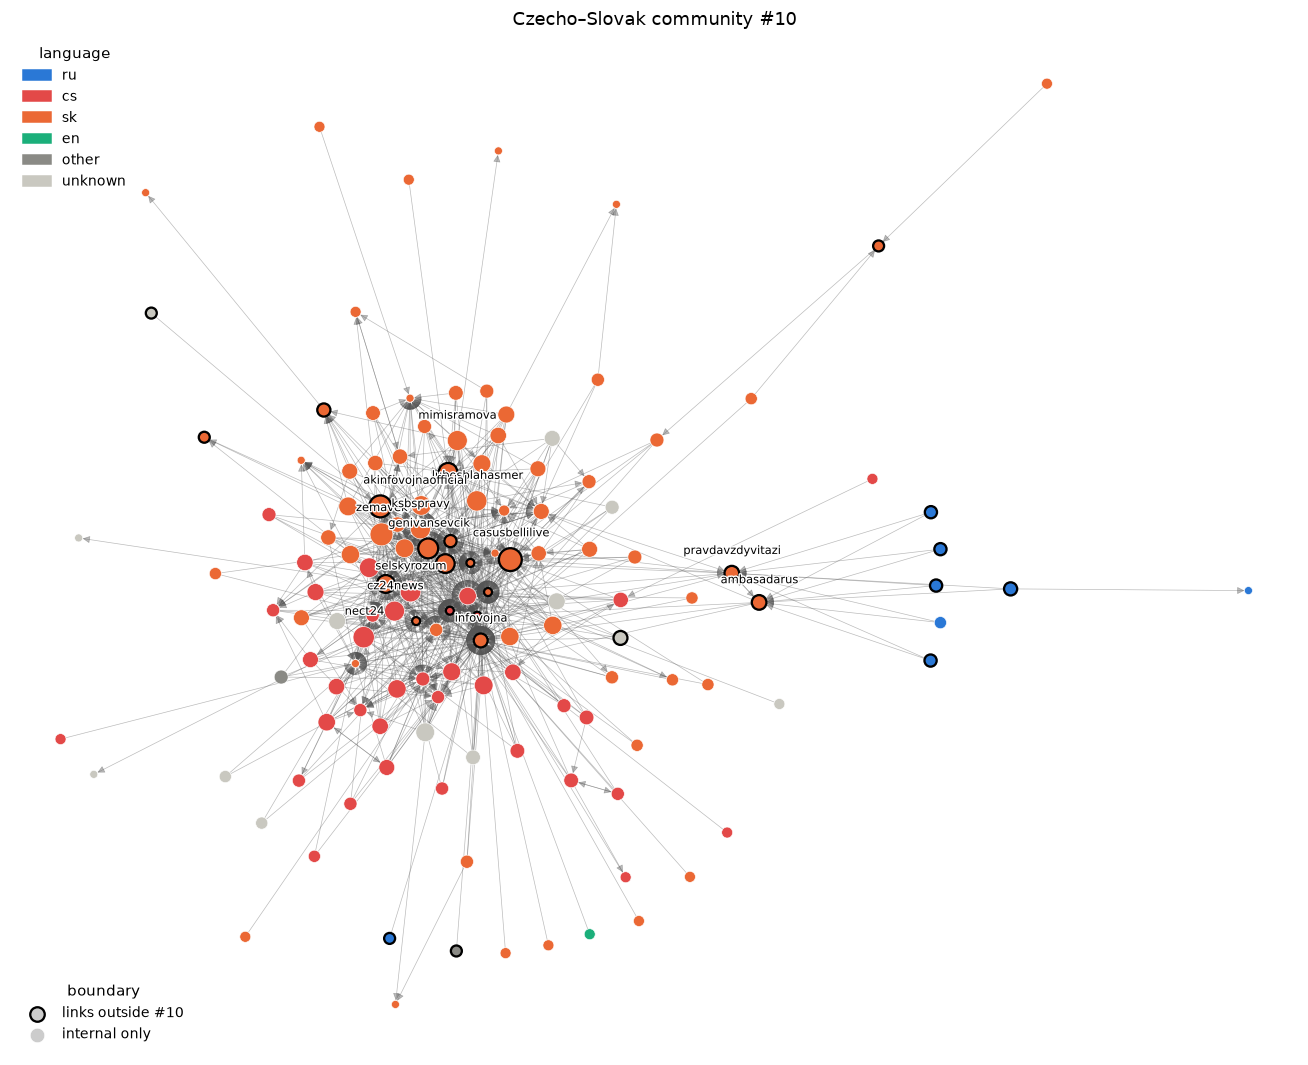

In [30]:
import random
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# ── re-run to try a different layout of community 10 ──────────────────────
LAYOUT_SEED = 476748    # change to reroll; None = fresh random spread each run (printed below)
LAYOUT_ALGO = 'fr'      # 'fr' | 'kk' | 'drl' | 'graphopt'
r_max       = 0.015     # radius of the largest node (in the normalized layout frame)
SPREAD      = 0         # 0 = keep the raw layout; >0 pushes overlapping nodes apart
USE_WEIGHTS = False     # weight FR/DRL by forward frequency (log counts): frequent pairs sit closer
# ──────────────────────────────────────────────────────────────────────────
CZSK = 10

members = np.where(c10_memb == CZSK)[0]
sub     = G.induced_subgraph(members.tolist())           # directed subgraph, internal edges only
snames  = np.array(sub.vs['name'])
slang   = np.array(sub.vs['lang'])
reach   = np.array(sub.degree(mode='out'))               # internal reach (peers reposting it)
n       = sub.vcount()

# flag nodes that also link outside the community (bridges)
member_set = set(members.tolist())
_imp, _exp = Counter(), Counter()
for e in G.es:
    s, t = e.source, e.target
    if s in member_set and t not in member_set:
        _exp[s] += 1
    elif t in member_set and s not in member_set:
        _imp[t] += 1
ext = np.array([_imp.get(i, 0) + _exp.get(i, 0) for i in members])
is_bridge = ext > 0

if LAYOUT_SEED is None:
    LAYOUT_SEED = int(np.random.default_rng().integers(0, 1_000_000))
print(f'layout seed = {LAYOUT_SEED}   (copy into LAYOUT_SEED to lock it in)')
random.seed(LAYOUT_SEED)
start = np.random.default_rng(LAYOUT_SEED).uniform(-1, 1, (n, 2)).tolist()

# optional edge weights = log(1 + #forwards); layout-only (counts dominated by channel->chat auto-forwards)
_w = None
if USE_WEIGHTS:
    _cnt = {(r['origin'], r['target']): int(r['count'])
            for r in csv.DictReader(open(DATA / 'edges_forward.csv'))}
    _w = [float(np.log1p(_cnt.get((snames[e.source], snames[e.target]), 1))) for e in sub.es]

if LAYOUT_ALGO == 'fr':
    lay = sub.layout_fruchterman_reingold(niter=800, seed=start, weights=_w)
elif LAYOUT_ALGO == 'kk':
    lay = sub.layout_kamada_kawai(seed=start)
elif LAYOUT_ALGO == 'drl':
    lay = sub.layout_drl(weights=_w)
elif LAYOUT_ALGO == 'graphopt':
    lay = sub.layout_graphopt(niter=1000)
xy = np.array(lay.coords, float); xy -= xy.mean(0); xy /= np.abs(xy).max() + 1e-9

# node radius: area ∝ internal reach, capped at r_max (floor so reach-0 nodes stay visible)
rad = r_max * (0.35 + 0.65 * np.sqrt(reach) / max(np.sqrt(reach.max()), 1))

if SPREAD > 0:
    for _ in range(400):
        moved = False
        for i in range(n):
            for j in range(i + 1, n):
                d = xy[j] - xy[i]; dist = float(np.hypot(*d)); md = (rad[i] + rad[j]) * SPREAD
                if dist < md:
                    if dist < 1e-9:
                        d = np.array([1e-3 * (j - i + 1), 1e-3]); dist = float(np.hypot(*d))
                    sh = (md - dist) / 2; u = d / dist
                    xy[i] -= u * sh; xy[j] += u * sh; moved = True
        if not moved:
            break
x, y = xy[:, 0], xy[:, 1]

fig, ax = plt.subplots(figsize=(12, 11))

# DIRECTED internal forward edges — arrow origin -> forwarder, trimmed to the node radii
for e in sub.es:
    s, t = e.source, e.target
    p0 = np.array([x[s], y[s]]); p1 = np.array([x[t], y[t]])
    d = p1 - p0; L = float(np.hypot(*d))
    if L < 1e-9:
        continue
    u = d / L
    ax.annotate('', xy=p1 - u * rad[t], xytext=p0 + u * rad[s], zorder=1,
                arrowprops=dict(arrowstyle='-|>', color='#555555', lw=0.45, alpha=0.40,
                                shrinkA=0, shrinkB=0, mutation_scale=10))

# nodes as circles: colour = language; bridges get a black outline
for i in range(n):
    ax.add_patch(mpatches.Circle(
        (x[i], y[i]), rad[i], facecolor=LANG_COLORS.get(slang[i], LANG_COLORS['other']),
        edgecolor='black' if is_bridge[i] else 'white',
        linewidth=1.5 if is_bridge[i] else 0.4, zorder=3 if is_bridge[i] else 2))

# label the main hubs / bridges, nudged just above the node
for i in np.argsort(reach + ext)[::-1][:14]:
    ax.text(x[i], y[i] + rad[i] + 0.012, snames[i], fontsize=7.5, ha='center', va='bottom',
            zorder=4, path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])

present = [l for l in ['ru', 'cs', 'sk', 'uk', 'en', 'other', 'unknown'] if l in set(slang)]
leg1 = ax.legend(handles=[mpatches.Patch(color=LANG_COLORS[l], label=l) for l in present],
                 loc='upper left', frameon=False, fontsize=9, title='language')
ax.add_artist(leg1)
ax.legend(handles=[
    plt.scatter([], [], s=90, facecolor='#cccccc', edgecolor='black', linewidths=1.5,
                label=f'links outside #{CZSK}'),
    plt.scatter([], [], s=90, facecolor='#cccccc', edgecolor='white', linewidths=0.4,
                label='internal only')],
    loc='lower left', frameon=False, fontsize=9, title='boundary')

mrg = r_max + 0.05
ax.set_xlim(x.min() - mrg, x.max() + mrg); ax.set_ylim(y.min() - mrg, y.max() + mrg)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(f'Czecho–Slovak community #{CZSK}')
plt.tight_layout(); plt.show()

### Figure 6 · Internal influence vs importing from outside

*Thesis Figure 6: content-reservoir vs importer roles in the Czecho-Slovak community.*

Each channel placed by its role: **internal reach** (x, how many community peers repost it)
against **imports from outside** (y, how many outside sources it reposts). The quadrants
separate *importers* (top-left), *reservoirs* (bottom-right), and *gateways* that do both
(top-right). This is the division of labour the chapter reads off — and the reason
@nect24 and @selskyrozum, prominent reservoirs, import nothing from Russian channels.
Colour = language; small jitter de-overlaps the many points at zero.

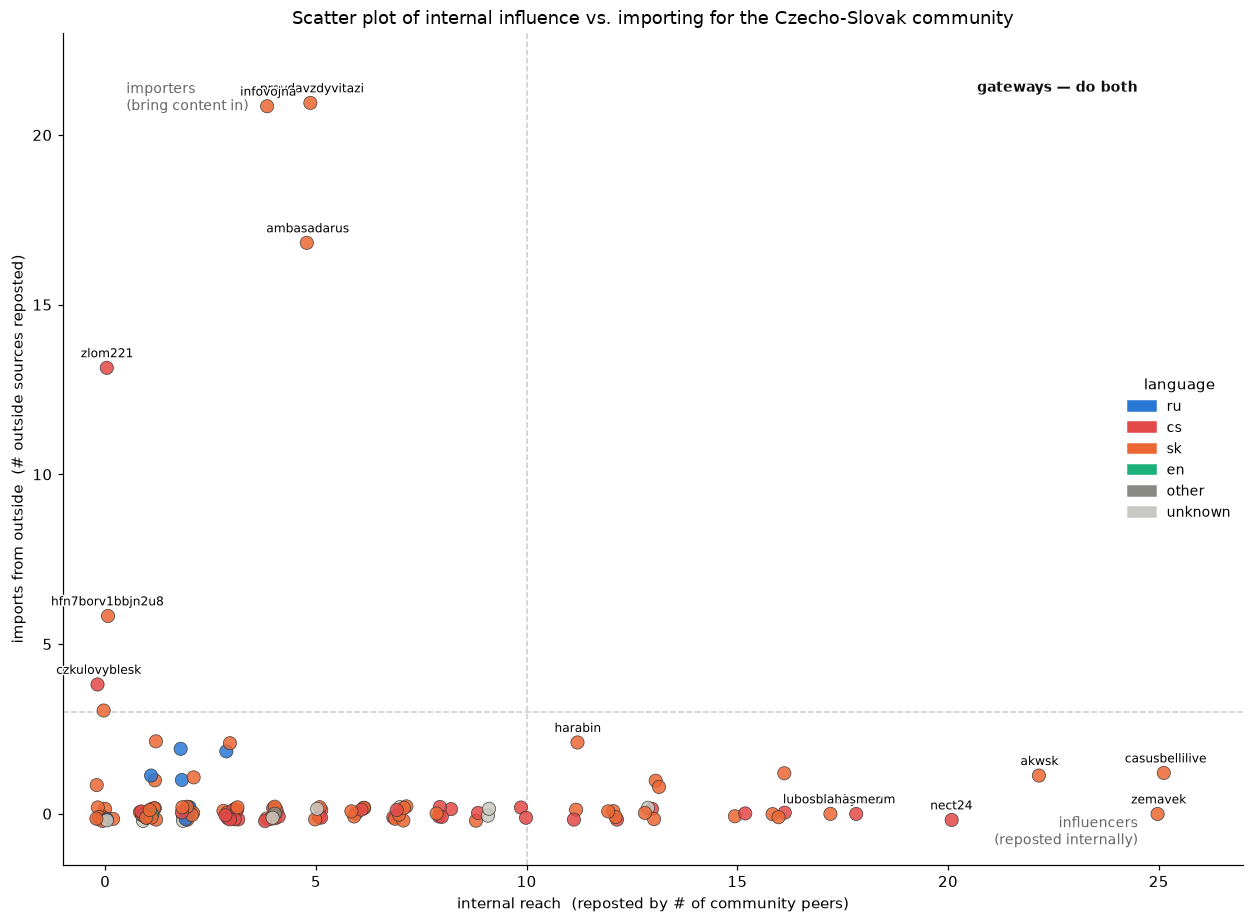

In [31]:
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

# per-channel table: internal reach (out-degree in-community) vs imports from outside (external in-deg)
_midx = np.where(c10_memb == C10)[0]; _mset = set(_midx.tolist())
_sub = G.induced_subgraph(_midx.tolist())
_reach_int = np.array(_sub.degree(mode='out'))       # reposted by # community peers (influence)
_imports_int = np.array(_sub.degree(mode='in'))      # aggregator inside the community
_impext, _expext = Counter(), Counter()
for e in G.es:
    s, t = e.source, e.target
    if t in _mset and s not in _mset:
        _impext[t] += 1
    elif s in _mset and t not in _mset:
        _expext[s] += 1
_imports_ext = np.array([_impext.get(i, 0) for i in _midx])   # imports from outside
_reach_ext   = np.array([_expext.get(i, 0) for i in _midx])
tbl = pd.DataFrame({
    'handle': c10_gv[_midx], 'lang': np.array(G.vs['lang'])[_midx],
    'type': [type_of.get(c10_gv[i], '?') for i in _midx],
    'reach_int': _reach_int, 'imports_int': _imports_int,
    'imports_ext': _imports_ext, 'reach_ext': _reach_ext,
}).sort_values(['reach_int', 'imports_ext'], ascending=False).reset_index(drop=True)

d  = tbl.copy()
ri = d['reach_int'].to_numpy(float)          # x — influence within the community
ie = d['imports_ext'].to_numpy(float)        # y — imports from outside
bal = np.sqrt(ri * ie)                        # balance: high only if BOTH are high
handles = d['handle'].to_numpy(); langs_ = d['lang'].to_numpy()

# small deterministic jitter so the many (x, 0) points don't stack
rng = np.random.default_rng(SEED)
x = ri + rng.uniform(-0.22, 0.22, len(ri))
y = ie + rng.uniform(-0.22, 0.22, len(ie))
colors = [LANG_COLORS.get(l, LANG_COLORS['other']) for l in langs_]

fig, ax = plt.subplots(figsize=(11.5, 8.5))
XT, YT = 10, 3
ax.axvline(XT, color='#cccccc', ls='--', lw=1, zorder=0)
ax.axhline(YT, color='#cccccc', ls='--', lw=1, zorder=0)
ax.text(0.5, ie.max() + 0.6, 'importers\n(bring content in)', fontsize=9, color='#666', va='top')
ax.text(ri.max() - 0.5, -0.9, 'influencers\n(reposted internally)', fontsize=9, color='#666', ha='right')
ax.text(ri.max() - 0.5, ie.max() + 0.6, 'gateways — do both', fontsize=9, color='#111',
        ha='right', va='top', fontweight='bold')

ax.scatter(x, y, s=75, c=colors, edgecolors='#333', linewidths=0.5, alpha=0.85, zorder=2)

lab = set(np.argsort(ri)[::-1][:6].tolist()
          + np.argsort(ie)[::-1][:6].tolist()
          + np.argsort(bal)[::-1][:6].tolist())
for i in lab:
    ax.annotate(handles[i], (x[i], y[i]), fontsize=8, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points', zorder=4,
                path_effects=[pe.withStroke(linewidth=1.8, foreground='white')])

present = [l for l in ['ru', 'cs', 'sk', 'uk', 'en', 'other', 'unknown'] if l in set(langs_)]
ax.legend(handles=[mpatches.Patch(color=LANG_COLORS[l], label=l) for l in present],
          loc='center right', frameon=False, fontsize=9, title='language')
ax.set_xlabel('internal reach  (reposted by # of community peers)')
ax.set_ylabel('imports from outside  (# outside sources reposted)')
ax.set_xlim(-1, ri.max() + 2); ax.set_ylim(-1.5, ie.max() + 2)
ax.set_title(f'Scatter plot of internal influence vs. importing for the Czecho-Slovak community')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout(); plt.show()

---

## Appendix · Supplementary checks

Not cited in the thesis. Kept because they bear on claims the chapter does make.

### A1 · Are the degree hubs channels or groups?

The chapter distinguishes broadcast **channels** from **groups** (chats) and flags groups as
structural actors. This splits the **top-100 in-degree** nodes (aggregators) and the
**top-100 out-degree** nodes (origins) by node type, against the whole-giant-WCC baseline —
the pan-network counterpart of the community-10 group/channel split above.

In [32]:
names = np.array(G.vs['name'])
node_type = np.array([type_of.get(h, 'unknown') for h in names])
top_in  = np.argsort(ind)[::-1][:100]
top_out = np.argsort(outd)[::-1][:100]

order = ['channel', 'group'] + sorted(set(node_type) - {'channel', 'group'})
def col(idx, denom):
    vc = pd.Series(node_type[idx]).value_counts()
    return {t: f'{int(vc.get(t, 0))} ({vc.get(t, 0) / denom:.0%})' for t in order}

hub_types = pd.DataFrame({
    'top-100 in-degree (aggregators)': col(top_in, 100),
    'top-100 out-degree (origins)':    col(top_out, 100),
    'all giant-WCC nodes':             col(np.arange(len(node_type)), len(node_type)),
}).reindex(order)
display(hub_types)

for lbl, idx in [('in-degree', top_in), ('out-degree', top_out)]:
    grp = sorted(names[idx][node_type[idx] == 'group'].tolist())
    print(f'groups among top-100 {lbl} ({len(grp)}): {grp}')


,top-100 in-degree (aggregators),top-100 out-degree (origins),all giant-WCC nodes
channel,92 (92%),100 (100%),6981 (97%)
group,8 (8%),0 (0%),124 (2%)
empty,0 (0%),0 (0%),123 (2%)
unknown,0 (0%),0 (0%),1 (0%)


groups among top-100 in-degree (8): ['armsilaruchat', 'bgbzc', 'infovojna', 'lohmatiyz', 'operlinechat', 'rubej99_chat', 'trackamercchat', 'zhizn_fm_chat']
groups among top-100 out-degree (0): []
